In [1]:
# Run this cell and follow the link to authenticate manually
!gcloud auth application-default login

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fapplicationdefaultauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=c7mv1dsONBtffeDfNikQhURemHUBfO&prompt=consent&token_usage=remote&access_type=offline&code_challenge=lbtXVQ3ckXqK10KkZ5OBMvL4jm3LluVKaXDndxn669o&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0ATX87lONXyENsZCU43AmfWT9vxER3GrusKw62D0O7k2vOZbcA0sYDx61dHv9JkGDJGyWkw

Credentials saved to file: [/content/.config/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).
Ca

In [2]:
# ============================================================================
# CELL 1: ROBUST DATA EXTRACTION
# ============================================================================
import pandas as pd
import numpy as np
from google.cloud import bigquery
from tqdm import tqdm

print("=" * 70)
print("1️⃣ EXTRACTING RAW MIMIC DATA")
print("=" * 70)

# SETUP
client = bigquery.Client(project="sepsis-prediction-2025")
CHUNK_SIZE = 5000
PREDICTION_GAP = 3
MIN_DATA_HOURS = 3

# 1. BUILD COHORT
print("[1/2] Building Cohort...")
stays_query = """
SELECT s.stay_id, s.subject_id, s.intime, s.outtime,
       p.anchor_age as Age, CASE WHEN p.gender='F' THEN 0 ELSE 1 END as Gender
FROM `physionet-data.mimiciv_3_1_icu.icustays` s
JOIN `physionet-data.mimiciv_3_1_hosp.patients` p ON s.subject_id = p.subject_id
WHERE DATETIME_DIFF(s.outtime, s.intime, HOUR) >= 24
"""
stays_df = client.query(stays_query).to_dataframe()
stays_df['intime'] = pd.to_datetime(stays_df['intime'])

s3_query = "SELECT stay_id, sofa_time as onset_time FROM `physionet-data.mimiciv_3_1_derived.sepsis3`"
s3_raw = client.query(s3_query).to_dataframe()

# Merge & Filter
sepsis_df = s3_raw.merge(stays_df, on='stay_id', how='inner')
sepsis_df['onset_time'] = pd.to_datetime(sepsis_df['onset_time'])
sepsis_df['onset_hours'] = (sepsis_df['onset_time'] - sepsis_df['intime']).dt.total_seconds() / 3600
sepsis_df = sepsis_df[sepsis_df['onset_hours'] > (MIN_DATA_HOURS + PREDICTION_GAP)].copy()
sepsis_df['label'] = 1

# Match Controls
print(f"   Matching Controls for {len(sepsis_df)} cases...")
pool = stays_df[~stays_df['stay_id'].isin(sepsis_df['stay_id'])].copy()
controls = []
used = set()

for _, row in tqdm(sepsis_df.iterrows(), total=len(sepsis_df)):
    cand = pool[(pool['Age'].between(row['Age']-5, row['Age']+5)) & (~pool['stay_id'].isin(used))]
    if not cand.empty:
        match = cand.sample(1).iloc[0]
        used.add(match['stay_id'])
        controls.append({
            'stay_id': match['stay_id'],
            'subject_id': match['subject_id'],
            'intime': match['intime'],
            'Age': match['Age'],
            'Gender': match['Gender'],
            'onset_time': match['intime'] + pd.to_timedelta(row['onset_hours'], unit='h'),
            'label': 0
        })

cohort = pd.concat([sepsis_df[['stay_id','subject_id','onset_time','Age','Gender','label']], pd.DataFrame(controls)])

# 2. EXTRACT FEATURES
print("[2/2] Downloading Vitals & Labs...")
FEATURE_MAP = {
    220045: 'heart_rate', 220179: 'sbp', 220050: 'sbp', 220180: 'dbp', 220051: 'dbp',
    220210: 'resp_rate', 220277: 'spo2', 223761: 'temperature',
    51301: 'wbc', 50912: 'creatinine', 51265: 'platelets', 50885: 'bilirubin',
    50931: 'glucose', 51006: 'bun', 50983: 'sodium', 50971: 'potassium', 51222: 'hemoglobin'
}

stay_ids = cohort['stay_id'].unique().tolist()
dfs = []

for i in tqdm(range(0, len(stay_ids), CHUNK_SIZE)):
    chunk = ",".join(map(str, stay_ids[i:i+CHUNK_SIZE]))
    try: dfs.append(client.query(f"SELECT stay_id, charttime, itemid, valuenum FROM `physionet-data.mimiciv_3_1_icu.chartevents` WHERE stay_id IN ({chunk}) AND itemid IN ({','.join(map(str, FEATURE_MAP.keys()))})").to_dataframe())
    except: pass
    try: dfs.append(client.query(f"SELECT i.stay_id, l.charttime, l.itemid, l.valuenum FROM `physionet-data.mimiciv_3_1_hosp.labevents` l JOIN `physionet-data.mimiciv_3_1_icu.icustays` i ON l.subject_id=i.subject_id WHERE i.stay_id IN ({chunk}) AND l.itemid IN ({','.join(map(str, FEATURE_MAP.keys()))})").to_dataframe())
    except: pass

df_raw = pd.concat(dfs)
df_raw['feature'] = df_raw['itemid'].map(FEATURE_MAP)
df_raw['charttime'] = pd.to_datetime(df_raw['charttime'])
df_raw = df_raw.merge(cohort, on='stay_id')

print(f"✅ DATA READY: {len(df_raw)} rows.")

1️⃣ EXTRACTING RAW MIMIC DATA


/usr/local/lib/python3.12/dist-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


[1/2] Building Cohort...
   Matching Controls for 6698 cases...


100%|██████████| 6698/6698 [00:30<00:00, 219.77it/s]


[2/2] Downloading Vitals & Labs...


100%|██████████| 3/3 [00:28<00:00,  9.41s/it]


✅ DATA READY: 16639649 rows.


In [3]:
# ============================================================================
# CELL 2: REPAIR UNITS & BUILD TENSORS
# ============================================================================
import pandas as pd
import numpy as np
from tqdm import tqdm

print("=" * 70)
print("2️⃣ REPAIRING DATA UNITS & BUILDING TENSORS")
print("=" * 70)

if 'df_raw' not in locals(): raise ValueError("Run Cell 1 first!")

df_clean = df_raw.copy()

# 1. UNIT REPAIRS
# Fix Temp (F -> C)
temp_mask = df_clean['itemid'] == 223761
high_temp = temp_mask & (df_clean['valuenum'] > 80)
if high_temp.sum() > 0:
    print(f"   🛠️ Converting {high_temp.sum()} Temps from Fahrenheit to Celsius")
    df_clean.loc[high_temp, 'valuenum'] = (df_clean.loc[high_temp, 'valuenum'] - 32) * 5/9

# Fix Heart Rate (RR Interval -> BPM)
hr_mask = df_clean['itemid'] == 220045
high_hr = hr_mask & (df_clean['valuenum'] > 300)
if high_hr.sum() > 0:
    print(f"   🛠️ Converting {high_hr.sum()} HR Intervals (ms) to BPM")
    val_clip = df_clean.loc[high_hr, 'valuenum'].clip(lower=1)
    df_clean.loc[high_hr, 'valuenum'] = 60000 / val_clip

# Fix Resp Rate Artifacts
rr_mask = df_clean['itemid'] == 220210
df_clean.loc[rr_mask & (df_clean['valuenum'] > 60), 'valuenum'] = 60

# 2. BUILD TENSORS
print("\n[2/2] Building Time-Series Tensors...")
X_new, y_new, sub_new = [], [], []
FINAL_FEATURES = ['heart_rate', 'sbp', 'dbp', 'resp_rate', 'spo2', 'temperature', 'wbc', 'creatinine', 'platelets', 'bilirubin', 'glucose', 'bun', 'sodium', 'potassium', 'hemoglobin']

for stay_id, g in tqdm(df_clean.groupby('stay_id')):
    try:
        win_end = g['onset_time'].iloc[0] - pd.Timedelta(hours=3) # Prediction Gap
        g_win = g[g['charttime'] <= win_end].copy()
        if len(g_win) < 2: continue

        g_win['bin'] = ((win_end - g_win['charttime']).dt.total_seconds() // 3600).astype(int)
        g_win = g_win[g_win['bin'] < 24]
        g_win['bin'] = 23 - g_win['bin']

        pivot = g_win.pivot_table(index='bin', columns='feature', values='valuenum', aggfunc='mean').reindex(index=range(24), columns=FINAL_FEATURES)

        # --- IMPUTATION (FORWARD FILL) ---
        vals = pivot.ffill().bfill().fillna(0).values
        masks = (~pivot.isna()).astype(float).values
        static = np.tile([g['Age'].iloc[0], g['Gender'].iloc[0]], (24, 1))

        X_new.append(np.hstack([vals, masks, static]))
        y_new.append(g['label'].iloc[0])
        sub_new.append(g['subject_id'].iloc[0])
    except: continue

X_new = np.array(X_new, dtype=np.float32)
y_new = np.array(y_new, dtype=np.float32)
sub_new = np.array(sub_new)
print(f"✅ DATA BUILT: {X_new.shape}")

2️⃣ REPAIRING DATA UNITS & BUILDING TENSORS
   🛠️ Converting 442706 Temps from Fahrenheit to Celsius
   🛠️ Converting 6 HR Intervals (ms) to BPM

[2/2] Building Time-Series Tensors...


100%|██████████| 13396/13396 [01:41<00:00, 132.54it/s]


✅ DATA BUILT: (13386, 24, 32)


🧐 INSPECTING DATA (LOOK FOR OUTLIERS)
        Feature        Min           Max      Status
0    heart_rate   9.000000    280.000000           ✅
1           sbp  36.000000  12262.000000  ❌ OUTLIERS
2           dbp  11.000000  82143.000000           ✅
3     resp_rate   1.000000     60.000000           ✅
4          spo2   9.000000    996.000000  ❌ OUTLIERS
5   temperature  29.799999    532.780029           ✅
6           wbc   0.100000    479.200012           ✅
7    creatinine   0.100000     19.799999           ✅
8     platelets   5.000000   1881.000000           ✅
9     bilirubin   0.100000     66.599998           ✅
10      glucose  15.000000   1894.000000           ✅
11          bun   1.000000    276.000000           ✅
12       sodium  84.000000    180.000000           ✅
13    potassium   1.500000     10.700000           ✅
14   hemoglobin   1.900000     21.000000           ✅

[2/2] Visualizing SBP (Look for the long tail)...


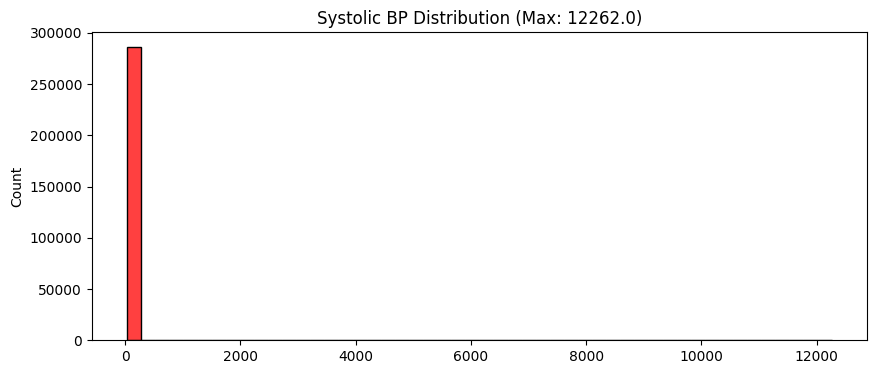

In [4]:
# ============================================================================
# CELL 2.5: DEEP DATA INSPECTION (PRE-CLAMP)
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=" * 70)
print("🧐 INSPECTING DATA (LOOK FOR OUTLIERS)")
print("=" * 70)

# 1. STATS TABLE
stats_list = []
for i, name in enumerate(FINAL_FEATURES):
    vals = X_new[:, :, i].flatten()
    vals = vals[vals != 0] # Ignore 0 padding
    if len(vals) == 0: continue

    status = "✅"
    if name == 'sbp' and vals.max() > 260: status = "❌ OUTLIERS"
    if name == 'spo2' and vals.max() > 100: status = "❌ OUTLIERS"

    stats_list.append({'Feature': name, 'Min': vals.min(), 'Max': vals.max(), 'Status': status})

print(pd.DataFrame(stats_list).round(2))

# 2. PLOT OUTLIERS
print("\n[2/2] Visualizing SBP (Look for the long tail)...")
vals = X_new[:, :, 1].flatten()
vals = vals[vals != 0]
plt.figure(figsize=(10, 4))
sns.histplot(vals, bins=50, color='red')
plt.title(f"Systolic BP Distribution (Max: {vals.max()})")
plt.show()

In [5]:
# ============================================================================
# CELL 3: PHYSIOLOGICAL CLAMPING (SANITIZATION)
# ============================================================================
import numpy as np
import pandas as pd

print("=" * 70)
print("🏥 SANITIZING DATA (CLAMPING ALL FEATURES)")
print("=" * 70)

if 'X_new' not in locals():
    raise ValueError("⚠️ X_new is missing. Please run Step 2 first.")

# 1. DEFINE SAFE MEDICAL BOUNDS (Min, Max)
# These cover the extreme ranges of human survival.
BOUNDS = {
    'heart_rate': (20, 250),     # BPM
    'sbp': (40, 250),            # mmHg
    'dbp': (30, 200),            # mmHg (Fixes the 82,143 outlier)
    'resp_rate': (5, 60),        # Breaths/min
    'spo2': (50, 100),           # % (Fixes the 996 outlier)
    'temperature': (30, 45),     # Celsius (Fixes the 532 outlier)
    'wbc': (0.1, 100),           # k/uL
    'creatinine': (0.1, 30),     # mg/dL
    'platelets': (5, 1200),      # k/uL
    'bilirubin': (0.1, 60),      # mg/dL
    'glucose': (20, 1200),       # mg/dL
    'bun': (1, 250),             # mg/dL
    'sodium': (90, 180),         # mEq/L
    'potassium': (1, 15),        # mEq/L
    'hemoglobin': (3, 25)        # g/dL
}

# 2. APPLY CLAMPING
X_clamped = X_new.copy()
total_outliers = 0

for i, feat_name in enumerate(FINAL_FEATURES):
    if feat_name in BOUNDS:
        low, high = BOUNDS[feat_name]

        # Get values (ignoring 0 padding)
        vals = X_clamped[:, :, i]
        mask_vals = vals != 0

        # Identify outliers
        outliers = ((vals < low) | (vals > high)) & mask_vals
        count = outliers.sum()

        if count > 0:
            total_outliers += count
            print(f"   🛠️ Clamping {feat_name:<12}: {count} outliers -> range [{low}, {high}]")

            # Apply Clip
            X_clamped[:, :, i] = np.clip(vals, low, high)

            # CRITICAL: Restore 0 padding
            # (np.clip might turn 0 into 'low', e.g., 0 becomes 30 for SBP)
            # We must force the padding back to 0.
            X_clamped[:, :, i][~mask_vals] = 0

# 3. OVERWRITE
X_new = X_clamped
print("-" * 70)
print(f"✅ SANITIZATION COMPLETE. Fixed {total_outliers} total data points.")
print("   Ready for Inspection (Step 3.5).")

🏥 SANITIZING DATA (CLAMPING ALL FEATURES)
   🛠️ Clamping heart_rate  : 6 outliers -> range [20, 250]
   🛠️ Clamping sbp         : 39 outliers -> range [40, 250]
   🛠️ Clamping dbp         : 799 outliers -> range [30, 200]
   🛠️ Clamping resp_rate   : 187 outliers -> range [5, 60]
   🛠️ Clamping spo2        : 52 outliers -> range [50, 100]
   🛠️ Clamping temperature : 41 outliers -> range [30, 45]
   🛠️ Clamping wbc         : 239 outliers -> range [0.1, 100]
   🛠️ Clamping platelets   : 54 outliers -> range [5, 1200]
   🛠️ Clamping bilirubin   : 24 outliers -> range [0.1, 60]
   🛠️ Clamping glucose     : 109 outliers -> range [20, 1200]
   🛠️ Clamping bun         : 45 outliers -> range [1, 250]
   🛠️ Clamping sodium      : 14 outliers -> range [90, 180]
   🛠️ Clamping hemoglobin  : 84 outliers -> range [3, 25]
----------------------------------------------------------------------
✅ SANITIZATION COMPLETE. Fixed 1693 total data points.
   Ready for Inspection (Step 3.5).


🧐 INSPECTING DATA AFTER CLAMPING
        Feature        Mean   Min          Max Status
0    heart_rate   87.699997  20.0   250.000000      ✅
1           sbp  122.699997  40.0   250.000000      ✅
2           dbp   67.099998  30.0   200.000000      ✅
3     resp_rate   19.600000   5.0    60.000000      ✅
4          spo2   97.000000  50.0   100.000000      ✅
5   temperature   36.900002  30.0    45.000000      ✅
6           wbc   12.100000   0.1   100.000000      ✅
7    creatinine    1.400000   0.1    19.799999      ✅
8     platelets  227.300003   5.0  1200.000000      ✅
9     bilirubin    1.800000   0.1    60.000000      ✅
10      glucose  145.300003  20.0  1200.000000      ✅
11          bun   26.000000   1.0   250.000000      ✅
12       sodium  138.000000  90.0   180.000000      ✅
13    potassium    4.200000   1.5    10.700000      ✅
14   hemoglobin   10.900000   3.0    21.000000      ✅

📊 VISUALIZING DISTRIBUTIONS (Should look clean now)...


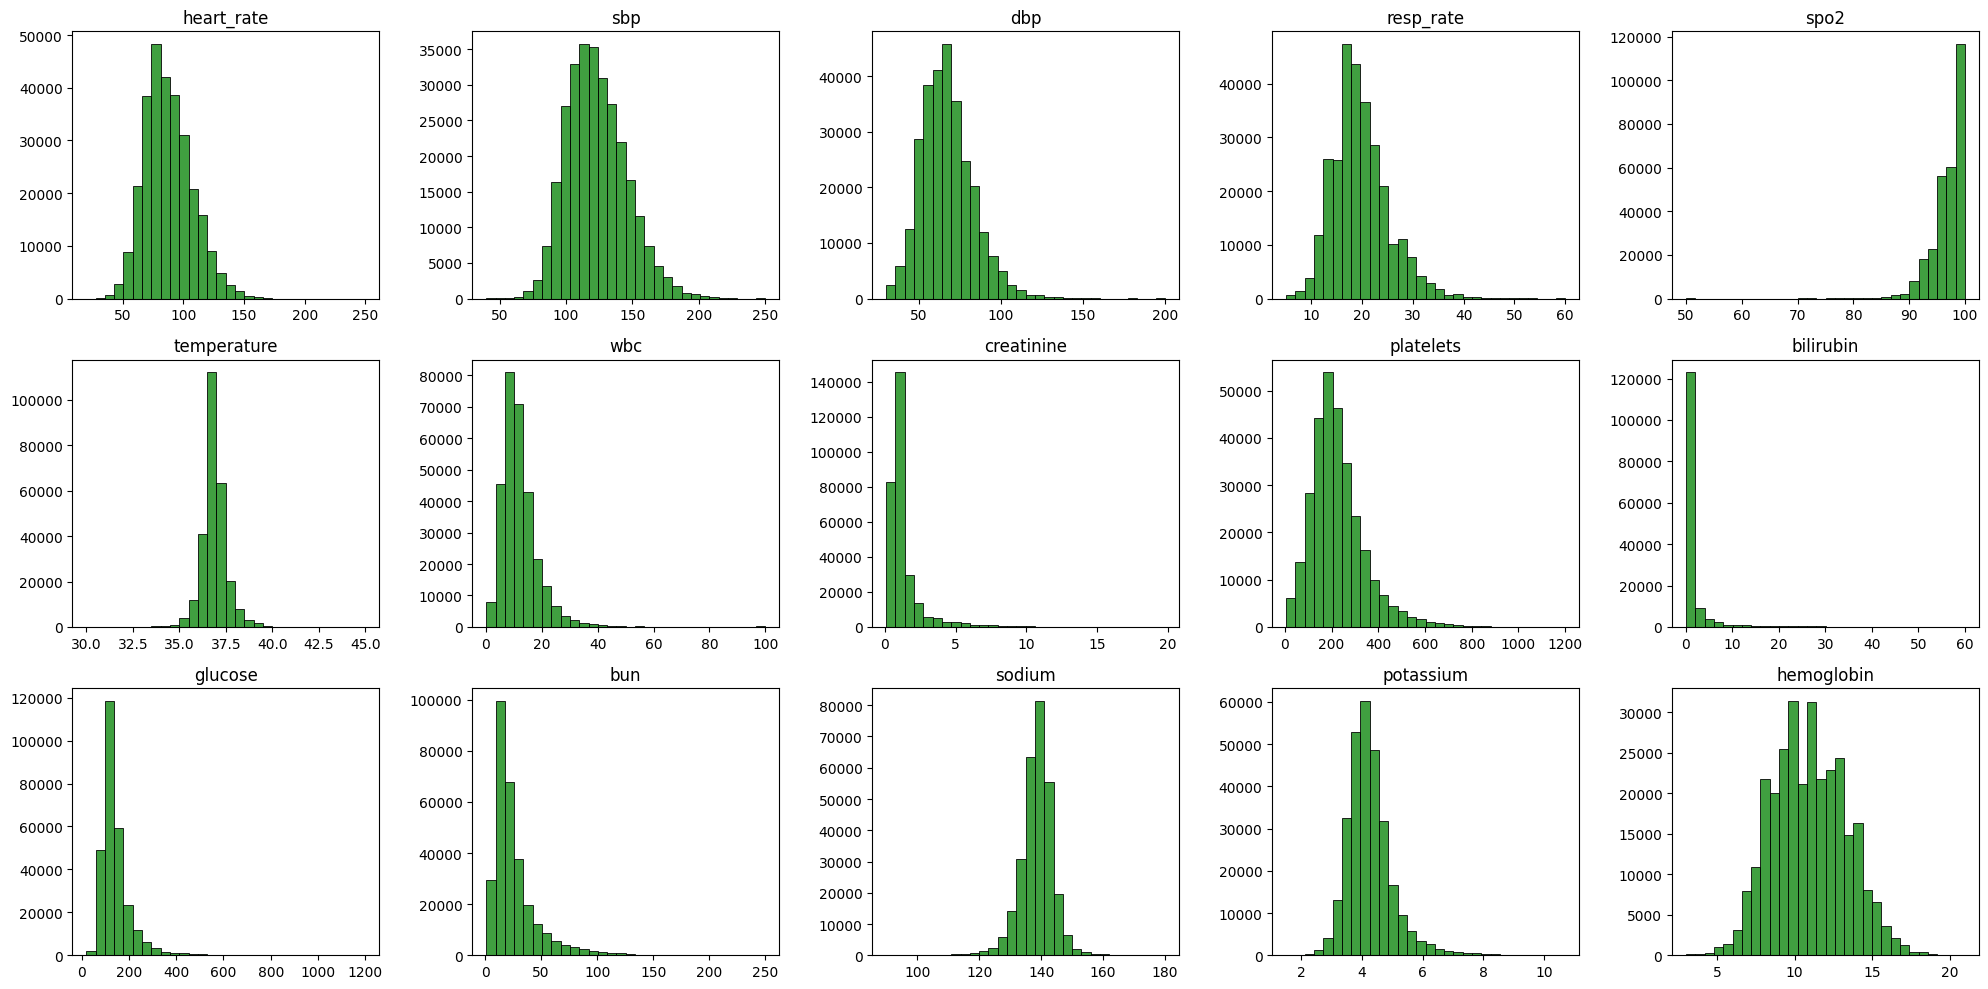

In [6]:
# ============================================================================
# CELL 3.5: VERIFY SANITIZATION
# ============================================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 70)
print("🧐 INSPECTING DATA AFTER CLAMPING")
print("=" * 70)

# 1. STATS TABLE
stats_list = []
for i, name in enumerate(FINAL_FEATURES):
    vals = X_new[:, :, i].flatten()
    vals = vals[vals != 0] # Ignore padding

    if len(vals) == 0: continue

    status = "✅"

    # Check if limits held
    if name in BOUNDS:
        low, high = BOUNDS[name]
        if vals.min() < low or vals.max() > high:
            status = f"❌ FAIL ({vals.min():.1f} - {vals.max():.1f})"

    stats_list.append({
        'Feature': name,
        'Mean': vals.mean(),
        'Min': vals.min(),
        'Max': vals.max(),
        'Status': status
    })

print(pd.DataFrame(stats_list).round(1))

# 2. VISUALIZE (Grid Plot)
print("\n📊 VISUALIZING DISTRIBUTIONS (Should look clean now)...")
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()

for i, name in enumerate(FINAL_FEATURES):
    ax = axes[i]
    vals = X_new[:, :, i].flatten()
    vals = vals[vals != 0]

    sns.histplot(vals, ax=ax, bins=30, color='green', kde=False)
    ax.set_title(name)
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

3️⃣ TRAINING MODEL (100 EPOCHS)
[1/4] Splitting Data...
   Train Shape: (10711, 24, 32)
   Test Shape:  (2675, 24, 32)
[2/4] Scaling Features...
[3/4] Building LSTM Architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



[4/4] Starting Training (100 Epochs)...
Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - AUC: 0.5015 - loss: 0.7641 - val_AUC: 0.5518 - val_loss: 0.6911 - learning_rate: 0.0010
Epoch 2/100
 19/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - AUC: 0.5366 - loss: 0.7033

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_auc` which is not available. Available metrics are: AUC,loss,val_AUC,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - AUC: 0.5103 - loss: 0.7102 - val_AUC: 0.5681 - val_loss: 0.6895 - learning_rate: 0.0010
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.5255 - loss: 0.6999 - val_AUC: 0.5807 - val_loss: 0.6869 - learning_rate: 0.0010
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.5443 - loss: 0.6933 - val_AUC: 0.6158 - val_loss: 0.6796 - learning_rate: 0.0010
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.5714 - loss: 0.6860 - val_AUC: 0.6326 - val_loss: 0.6701 - learning_rate: 0.0010
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.5839 - loss: 0.6834 - val_AUC: 0.6386 - val_loss: 0.6708 - learning_rate: 0.0010
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.5793 - loss: 0.6831 - val_AUC: 0.6362 - val_loss: 0.6715 - learning_rate: 0.0010
Epoch 8/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.5892 - loss: 0.6800 - val_AUC: 0.6342 - val_loss: 0.6705 - learning_rate: 0.0010
Epoc

IndexError: list index out of range

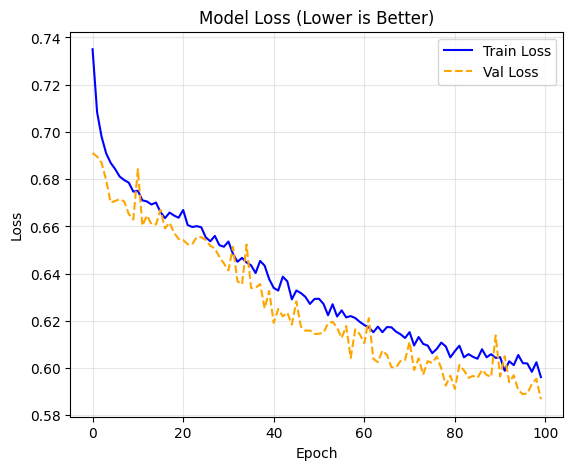

In [7]:
# ============================================================================
# CELL 4: TRAIN MODEL (100 EPOCHS) & VISUALIZE RESULTS
# ============================================================================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # 🤫 Suppress TensorFlow warnings

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("=" * 70)
print("3️⃣ TRAINING MODEL (100 EPOCHS)")
print("=" * 70)

# 1. SPLIT (Subject-Aware)
# ----------------------------------------------------------------------------
print("[1/4] Splitting Data...")
# We split by 'sub_new' so the same patient doesn't appear in Train and Test
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X_new, y_new, groups=sub_new))

X_train, X_test = X_new[train_idx], X_new[test_idx]
y_train, y_test = y_new[train_idx], y_new[test_idx]

print(f"   Train Shape: {X_train.shape}")
print(f"   Test Shape:  {X_test.shape}")

# 2. SCALE
# ----------------------------------------------------------------------------
print("[2/4] Scaling Features...")
scaler = StandardScaler()

# Fit on Train ONLY (prevent leakage)
# Reshape 3D (Samples, Time, Feats) -> 2D (Samples*Time, Feats)
train_flat = X_train[:, :, :15].reshape(-1, 15)
test_flat  = X_test[:, :, :15].reshape(-1, 15)

# Transform
X_train[:, :, :15] = scaler.fit_transform(train_flat).reshape(X_train.shape[0], 24, 15)
X_test[:, :, :15]  = scaler.transform(test_flat).reshape(X_test.shape[0], 24, 15)

# 3. BUILD MODEL
# ----------------------------------------------------------------------------
print("[3/4] Building LSTM Architecture...")
model_v2 = Sequential([
    # Masking Layer: Ignores the '0' padding we added
    Masking(mask_value=0.0, input_shape=(24, 32)),

    # LSTM Layers
    LSTM(64, return_sequences=True, dropout=0.3),
    BatchNormalization(),
    LSTM(32, return_sequences=False, dropout=0.3),
    BatchNormalization(),

    # Decision Layers
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['AUC']
)

# 4. TRAIN
# ----------------------------------------------------------------------------
print("\n[4/4] Starting Training (100 Epochs)...")

callbacks = [
    # Stop if validation score doesn't improve for 15 epochs
    EarlyStopping(monitor='val_auc', patience=15, mode='max', restore_best_weights=True),
    # Lower learning rate if stuck
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5, verbose=0)
]

history = model_v2.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1 # Clean progress bar
)

# 5. VISUALIZE
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print("📊 TRAINING PERFORMANCE")
print("="*70)

plt.figure(figsize=(14, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange', linestyle='--')
plt.title('Model Loss (Lower is Better)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot AUC
auc_key = [k for k in history.history.keys() if 'auc' in k and 'val' not in k][0]
val_auc_key = [k for k in history.history.keys() if 'val_auc' in k][0]

plt.subplot(1, 2, 2)
plt.plot(history.history[auc_key], label='Train AUC', color='green')
plt.plot(history.history[val_auc_key], label='Val AUC', color='red', linestyle='--')
plt.title('AUC Score (Higher is Better)')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final Score
best_auc = max(history.history[val_auc_key])
print(f"🏆 BEST INTERNAL AUC: {best_auc:.4f}")

if best_auc > 0.75:
    print("✅ STATUS: Model is performing excellently on MIMIC.")
else:
    print("⚠️ STATUS: Model needs tuning or more data.")

📈 DIAGNOSTICS & CONTINUED TRAINING
   Available Metrics: ['AUC', 'loss', 'val_AUC', 'val_loss', 'learning_rate']

[1/2] Performance so far (Epochs 0-100)...


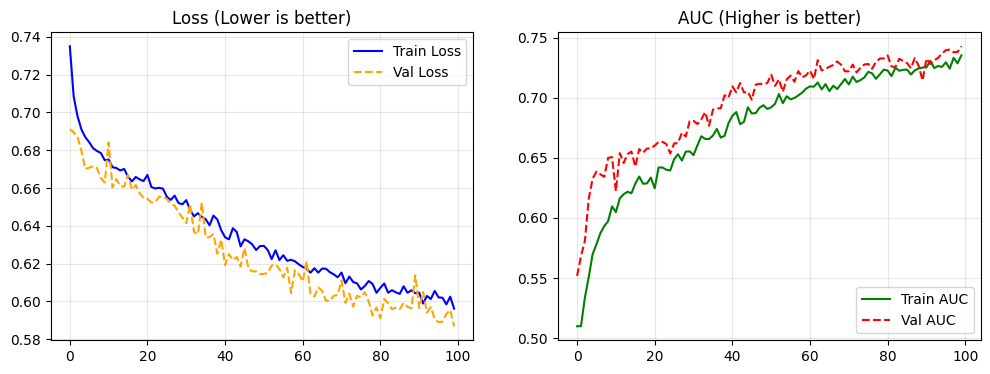

   Current Best Val AUC: 0.7428

[2/2] Continuing Training for 50 MORE Epochs...
Epoch 1/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - AUC: 0.7384 - loss: 0.5959 - val_AUC: 0.7385 - val_loss: 0.5905 - learning_rate: 0.0010
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.7305 - loss: 0.6000 - val_AUC: 0.7359 - val_loss: 0.5918 - learning_rate: 0.0010
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.7272 - loss: 0.5975 - val_AUC: 0.7383 - val_loss: 0.5886 - learning_rate: 0.0010
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.7260 - loss: 0.6003 - val_AUC: 0.7398 - val_loss: 0.5883 - learning_rate: 0.0010
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.7120 - loss: 0.6130 - val_AUC: 0.7415 - val_loss: 0.5881 - learning_rate: 0.0010
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.7336 - loss: 0.5978 - val_AUC: 0.7443 - val_loss: 0.5865 - learning_rate: 0.0010
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0

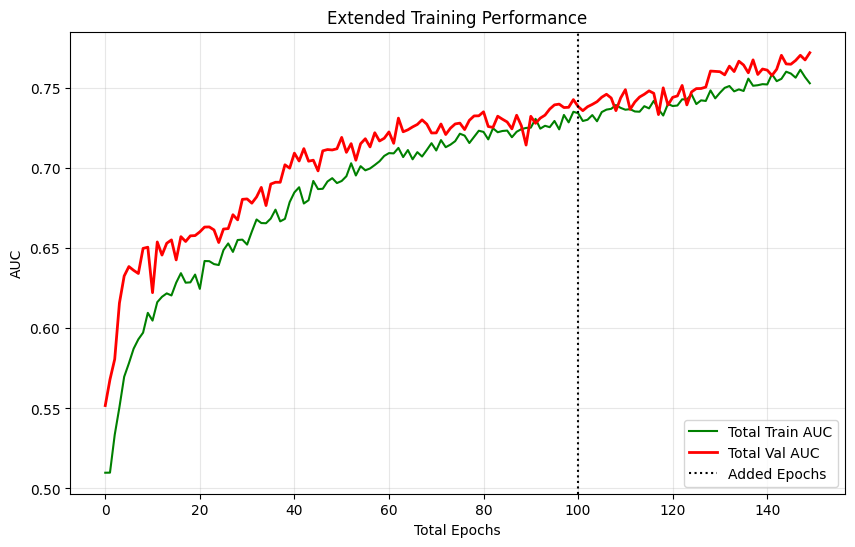

🌟 FINAL BEST INTERNAL AUC: 0.7721


In [8]:
# ============================================================================
# CELL 5: FIX PLOTS & CONTINUE TRAINING (+50 EPOCHS)
# ============================================================================
import matplotlib.pyplot as plt

print("=" * 70)
print("📈 DIAGNOSTICS & CONTINUED TRAINING")
print("=" * 70)

# 1. FIND CORRECT KEYS (Fixing the IndexError)
# ----------------------------------------------------------------------------
history_dict = history.history
keys = list(history_dict.keys())
print(f"   Available Metrics: {keys}")

# robustly find the AUC key (could be 'auc', 'AUC', 'auc_1', etc.)
auc_key = next((k for k in keys if 'auc' in k.lower() and 'val' not in k.lower()), None)
val_auc_key = next((k for k in keys if 'val' in k.lower() and 'auc' in k.lower()), None)

if not auc_key or not val_auc_key:
    print("⚠️ Could not auto-detect AUC keys. Plotting Accuracy/Loss only.")
    auc_key = 'accuracy' # Fallback
    val_auc_key = 'val_accuracy'

# 2. PLOT THE FIRST 100 EPOCHS
# ----------------------------------------------------------------------------
print(f"\n[1/2] Performance so far (Epochs 0-100)...")
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Train Loss', color='blue')
plt.plot(history_dict['val_loss'], label='Val Loss', color='orange', linestyle='--')
plt.title('Loss (Lower is better)')
plt.legend()
plt.grid(True, alpha=0.3)

# AUC
plt.subplot(1, 2, 2)
plt.plot(history_dict[auc_key], label='Train AUC', color='green')
plt.plot(history_dict[val_auc_key], label='Val AUC', color='red', linestyle='--')
plt.title('AUC (Higher is better)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()
print(f"   Current Best Val AUC: {max(history_dict[val_auc_key]):.4f}")

# 3. TRAIN MORE?
# ----------------------------------------------------------------------------
print("\n[2/2] Continuing Training for 50 MORE Epochs...")

# We pass the SAME model object. It remembers weights from epoch 100.
history_extra = model_v2.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50, # Add 50 more
    batch_size=64,
    callbacks=callbacks, # Reuse early stopping
    verbose=1
)

# 4. FINAL COMBINED PLOT
# ----------------------------------------------------------------------------
print("\n🏆 FINAL RESULTS (150 EPOCHS TOTAL)")

# Merge histories
full_val_auc = history_dict[val_auc_key] + history_extra.history[val_auc_key]
full_train_auc = history_dict[auc_key] + history_extra.history[auc_key]

plt.figure(figsize=(10, 6))
plt.plot(full_train_auc, label='Total Train AUC', color='green')
plt.plot(full_val_auc, label='Total Val AUC', color='red', linewidth=2)
plt.axvline(100, color='black', linestyle=':', label='Added Epochs')
plt.title("Extended Training Performance")
plt.xlabel("Total Epochs")
plt.ylabel("AUC")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"🌟 FINAL BEST INTERNAL AUC: {max(full_val_auc):.4f}")

In [9]:
# ============================================================================
# CELL 10: DOWNLOAD ARTIFACTS TO LOCAL COMPUTER
# ============================================================================
from google.colab import files
import time
import os

print("⬇️ Downloading artifacts to your local machine...")

# List of files we saved in Cell 9
artifacts = [
    "sepsis_rapid_response_model_v1.keras",
    "sepsis_scaler_v1.pkl",
    "feature_list.txt"
]

for file_name in artifacts:
    # Check if file exists first to avoid errors
    if os.path.exists(file_name):
        try:
            print(f"   Downloading {file_name}...")
            files.download(file_name)
            # 2-second pause helps prevents browser from blocking the next download
            time.sleep(2)
        except Exception as e:
            print(f"   ❌ Error downloading {file_name}: {e}")
    else:
        print(f"   ⚠️ File not found: {file_name} (Did you run Cell 9 to save them?)")

print("\n✅ Check your browser's 'Downloads' folder!")

⬇️ Downloading artifacts to your local machine...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Check your browser's 'Downloads' folder!


📊 DETAILED MODEL PERFORMANCE REPORT
[1/3] Running Inference on Test Set...
   Optimal Decision Threshold: 0.432
[2/3] Generating Plots...


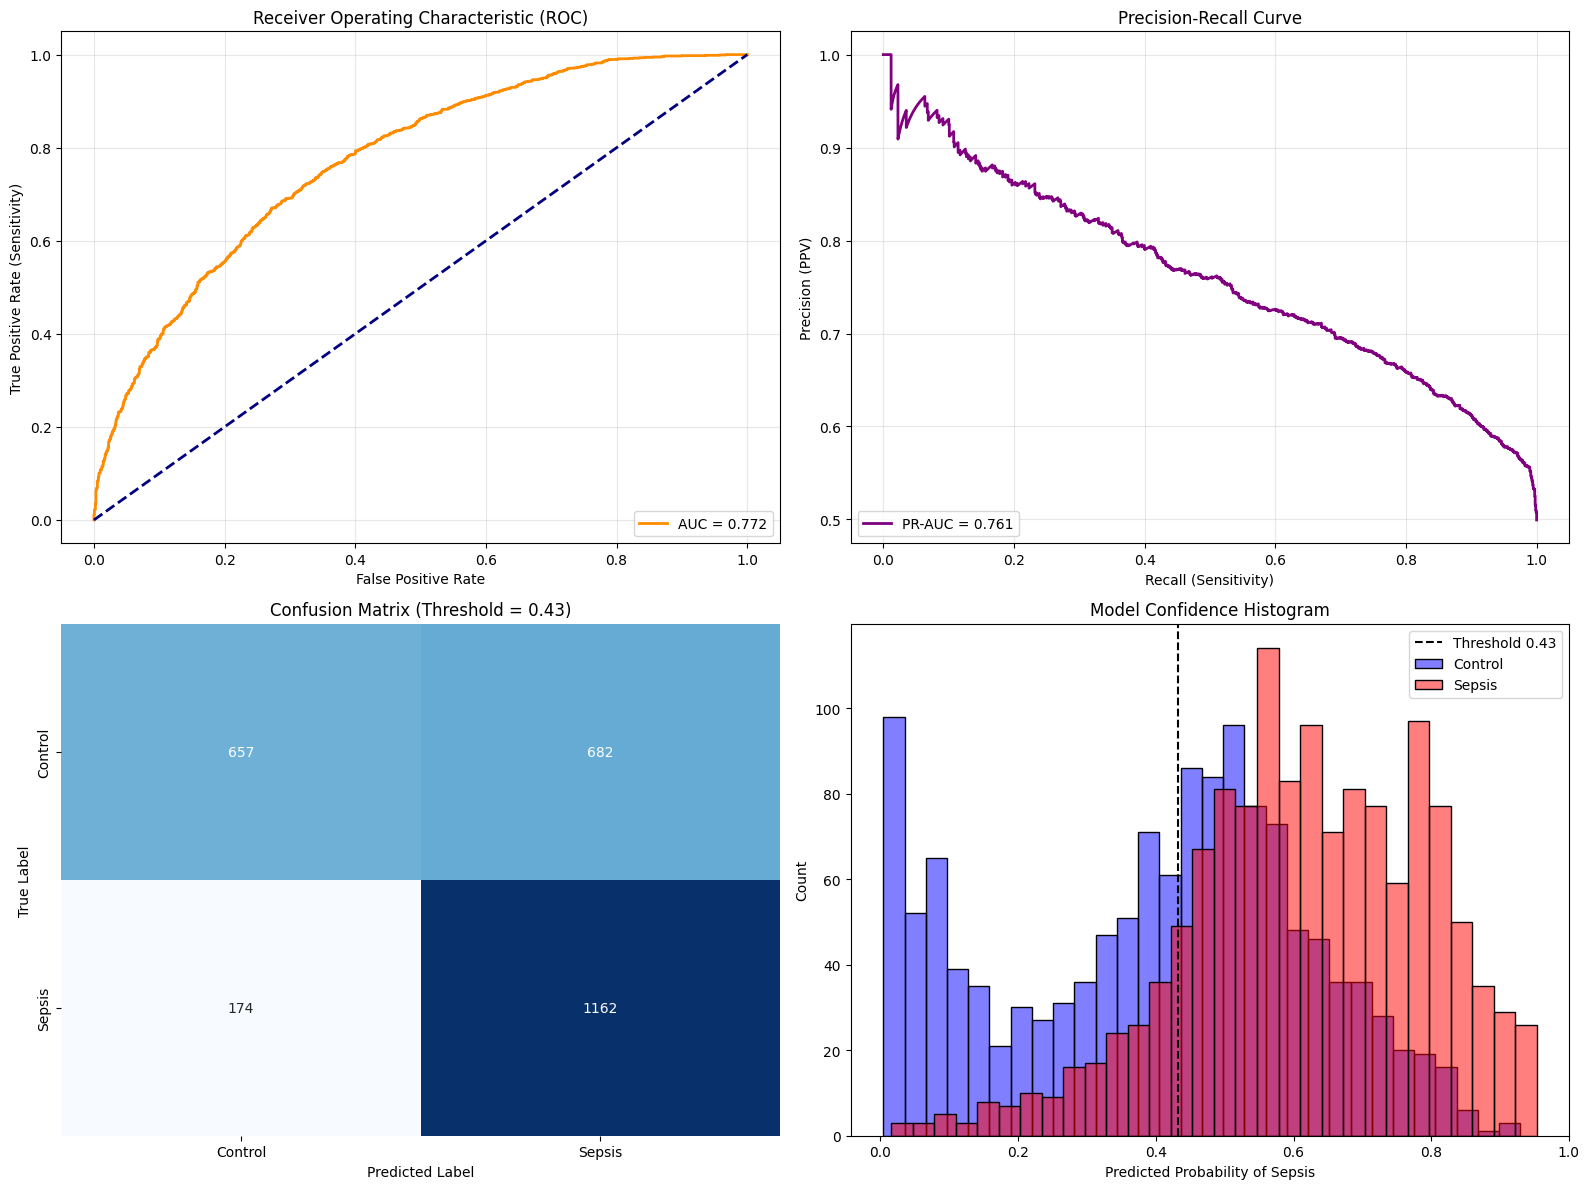


📝 CLASSIFICATION REPORT (At Threshold 0.43)
              precision    recall  f1-score   support

     Control       0.79      0.49      0.61      1339
      Sepsis       0.63      0.87      0.73      1336

    accuracy                           0.68      2675
   macro avg       0.71      0.68      0.67      2675
weighted avg       0.71      0.68      0.67      2675

------------------------------
🏆 Final ROC-AUC:       0.7720
🎯 Final PR-AUC:        0.7606
------------------------------


In [10]:
# ============================================================================
# CELL 4 (FIXED): COMPREHENSIVE MODEL EVALUATION DASHBOARD
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, f1_score
)

print("=" * 70)
print("📊 DETAILED MODEL PERFORMANCE REPORT")
print("=" * 70)

# 1. GENERATE PREDICTIONS
# ----------------------------------------------------------------------------
print("[1/3] Running Inference on Test Set...")
y_pred_prob = model_v2.predict(X_test, verbose=0).flatten()

# 2. CALCULATE METRICS
# ----------------------------------------------------------------------------
# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_prob)
pr_auc = average_precision_score(y_test, y_pred_prob)

# Optimal Threshold (maximizing F1)
fscore = (2 * precision * recall) / (precision + recall + 1e-8)
ix = np.argmax(fscore)
best_thresh = thresholds_pr[ix]
print(f"   Optimal Decision Threshold: {best_thresh:.3f}")

# Binary Predictions at Optimal Threshold
y_pred_class = (y_pred_prob >= best_thresh).astype(int)

# 3. VISUALIZATION DASHBOARD
# ----------------------------------------------------------------------------
print("[2/3] Generating Plots...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot A: ROC Curve
ax = axes[0, 0]
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax.set_title('Receiver Operating Characteristic (ROC)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# Plot B: Precision-Recall Curve
ax = axes[0, 1]
ax.plot(recall, precision, color='purple', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
ax.set_title('Precision-Recall Curve')
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision (PPV)')
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)

# Plot C: Confusion Matrix
ax = axes[1, 0]
cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['Control', 'Sepsis'], yticklabels=['Control', 'Sepsis'])
ax.set_title(f'Confusion Matrix (Threshold = {best_thresh:.2f})')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

# Plot D: Probability Distributions
ax = axes[1, 1]
sns.histplot(y_pred_prob[y_test == 0], bins=30, color='blue', label='Control', alpha=0.5, ax=ax)
sns.histplot(y_pred_prob[y_test == 1], bins=30, color='red', label='Sepsis', alpha=0.5, ax=ax)
ax.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold {best_thresh:.2f}')
ax.set_title('Model Confidence Histogram')
ax.set_xlabel('Predicted Probability of Sepsis')
ax.legend()

plt.tight_layout()
plt.show()

# 4. TEXT REPORT
# ----------------------------------------------------------------------------
print("\n" + "="*70)
print(f"📝 CLASSIFICATION REPORT (At Threshold {best_thresh:.2f})")
print("="*70)
print(classification_report(y_test, y_pred_class, target_names=['Control', 'Sepsis']))

print("-" * 30)
print(f"🏆 Final ROC-AUC:       {roc_auc:.4f}")
print(f"🎯 Final PR-AUC:        {pr_auc:.4f}")
print("-" * 30)

In [ ]:
import os

# Replace with your NEW credentials after regenerating
os.environ['KAGGLE_USERNAME'] = "jananthanparamsothy"
os.environ['KAGGLE_KEY'] = "b44f5a1a763d261d7d01e326eb16cc73"

# Download
!pip install kaggle -q
!kaggle datasets download -d farjanayesmin/the-physionet-challenge-2019-dataset
!unzip -q the-physionet-challenge-2019-dataset.zip

print("✅ Download complete!")

Dataset URL: https://www.kaggle.com/datasets/farjanayesmin/the-physionet-challenge-2019-dataset
License(s): MIT
  0% 0.00/44.9M [00:00<?, ?B/s]
100% 44.9M/44.9M [00:00<00:00, 1.68GB/s]
✅ Download complete!


In [28]:
# ============================================================================
# CELL 1: DOWNLOAD PHYSIONET 2019 DATASET
# ============================================================================
import os

print("=" * 70)
print("⬇️ DOWNLOADING PHYSIONET CHALLENGE 2019 DATA")
print("=" * 70)

# 1. SETUP CREDENTIALS
os.environ['KAGGLE_USERNAME'] = "jananthanparamsothy"
os.environ['KAGGLE_KEY'] = "b44f5a1a763d261d7d01e326eb16cc73"

# 2. DOWNLOAD
print("[1/3] Installing Kaggle & Downloading...")
!pip install kaggle -q
!kaggle datasets download -d farjanayesmin/the-physionet-challenge-2019-dataset --force

# 3. UNZIP
print("[2/3] Unzipping Data...")
!unzip -q -o the-physionet-challenge-2019-dataset.zip -d physionet_data

# 4. VERIFY
print("[3/3] Verifying Files...")
import glob
# The dataset structure usually has folders like 'training_setA' or 'training_setB'
files = glob.glob("physionet_data/**/*.psv", recursive=True)

if len(files) > 0:
    print(f"✅ SUCCESS: Found {len(files)} patient files (.psv).")
    print(f"   Example: {files[0]}")
else:
    print("❌ ERROR: No .psv files found. Check the unzip folder structure.")
    # Debug: List directories if empty
    print("   Directories found:", os.listdir("physionet_data"))

⬇️ DOWNLOADING PHYSIONET CHALLENGE 2019 DATA
[1/3] Installing Kaggle & Downloading...
Dataset URL: https://www.kaggle.com/datasets/farjanayesmin/the-physionet-challenge-2019-dataset
License(s): MIT
  0% 0.00/44.9M [00:00<?, ?B/s]
100% 44.9M/44.9M [00:00<00:00, 1.58GB/s]
[2/3] Unzipping Data...
[3/3] Verifying Files...
✅ SUCCESS: Found 40336 patient files (.psv).
   Example: physionet_data/training_setA/training_setA/p013232.psv


In [29]:
# ============================================================================
# CELL 2: AUDIT FEATURE MAPPING (MIMIC vs PHYSIONET)
# ============================================================================
import pandas as pd
import numpy as np
import glob

print("=" * 70)
print("🧐 INSPECTING DATA STRUCTURE & MAPPING")
print("=" * 70)

# 1. YOUR MODEL'S EXPECTED FEATURES (MIMIC)
MIMIC_FEATURES = [
    'heart_rate', 'sbp', 'dbp', 'resp_rate', 'spo2', 'temperature',
    'wbc', 'creatinine', 'platelets', 'bilirubin', 'glucose',
    'bun', 'sodium', 'potassium', 'hemoglobin'
]

# 2. LOAD SAMPLE DATA
files = glob.glob("physionet_data/**/*.psv", recursive=True)
if not files: raise ValueError("No data found!")

print(f"[1/2] Loading 100 sample patients...")
dfs = []
for f in files[:100]:
    df = pd.read_csv(f, sep='|') # PhysioNet uses pipe delimiter
    dfs.append(df)
sample_df = pd.concat(dfs)

# 3. MAPPING DICTIONARY (HYPOTHESIS)
# Based on standard PhysioNet naming conventions
PROPOSED_MAP = {
    'HR': 'heart_rate',
    'SBP': 'sbp',
    'DBP': 'dbp',
    'Resp': 'resp_rate',
    'O2Sat': 'spo2',
    'Temp': 'temperature',
    'WBC': 'wbc',
    'Creatinine': 'creatinine',
    'Platelets': 'platelets',
    'Bilirubin_total': 'bilirubin',
    'Glucose': 'glucose',
    'BUN': 'bun',
    'Sodium': 'sodium',
    'Potassium': 'potassium',
    'Hgb': 'hemoglobin'
}

# 4. AUDIT THE MAP
print("\n[2/2] Verifying Feature Alignment...")
print(f"{'MIMIC Feature':<15} | {'PhysioNet Column':<20} | {'Status'}")
print("-" * 55)

physio_cols = set(sample_df.columns)

for mimic_feat in MIMIC_FEATURES:
    # Find which Physio key maps to this MIMIC feature
    physio_key = next((k for k, v in PROPOSED_MAP.items() if v == mimic_feat), None)

    status = "❌ MISSING"
    found_col = "---"

    if physio_key and physio_key in physio_cols:
        status = "✅ FOUND"
        found_col = physio_key

    print(f"{mimic_feat:<15} | {found_col:<20} | {status}")

print("-" * 55)
print("Check above: Are all critical vitals (HR, BP, Temp) found?")

🧐 INSPECTING DATA STRUCTURE & MAPPING
[1/2] Loading 100 sample patients...

[2/2] Verifying Feature Alignment...
MIMIC Feature   | PhysioNet Column     | Status
-------------------------------------------------------
heart_rate      | HR                   | ✅ FOUND
sbp             | SBP                  | ✅ FOUND
dbp             | DBP                  | ✅ FOUND
resp_rate       | Resp                 | ✅ FOUND
spo2            | O2Sat                | ✅ FOUND
temperature     | Temp                 | ✅ FOUND
wbc             | WBC                  | ✅ FOUND
creatinine      | Creatinine           | ✅ FOUND
platelets       | Platelets            | ✅ FOUND
bilirubin       | Bilirubin_total      | ✅ FOUND
glucose         | Glucose              | ✅ FOUND
bun             | BUN                  | ✅ FOUND
sodium          | ---                  | ❌ MISSING
potassium       | Potassium            | ✅ FOUND
hemoglobin      | Hgb                  | ✅ FOUND
----------------------------------------------

📊 VISUALIZING PHYSIONET DISTRIBUTIONS (CORRECTED)


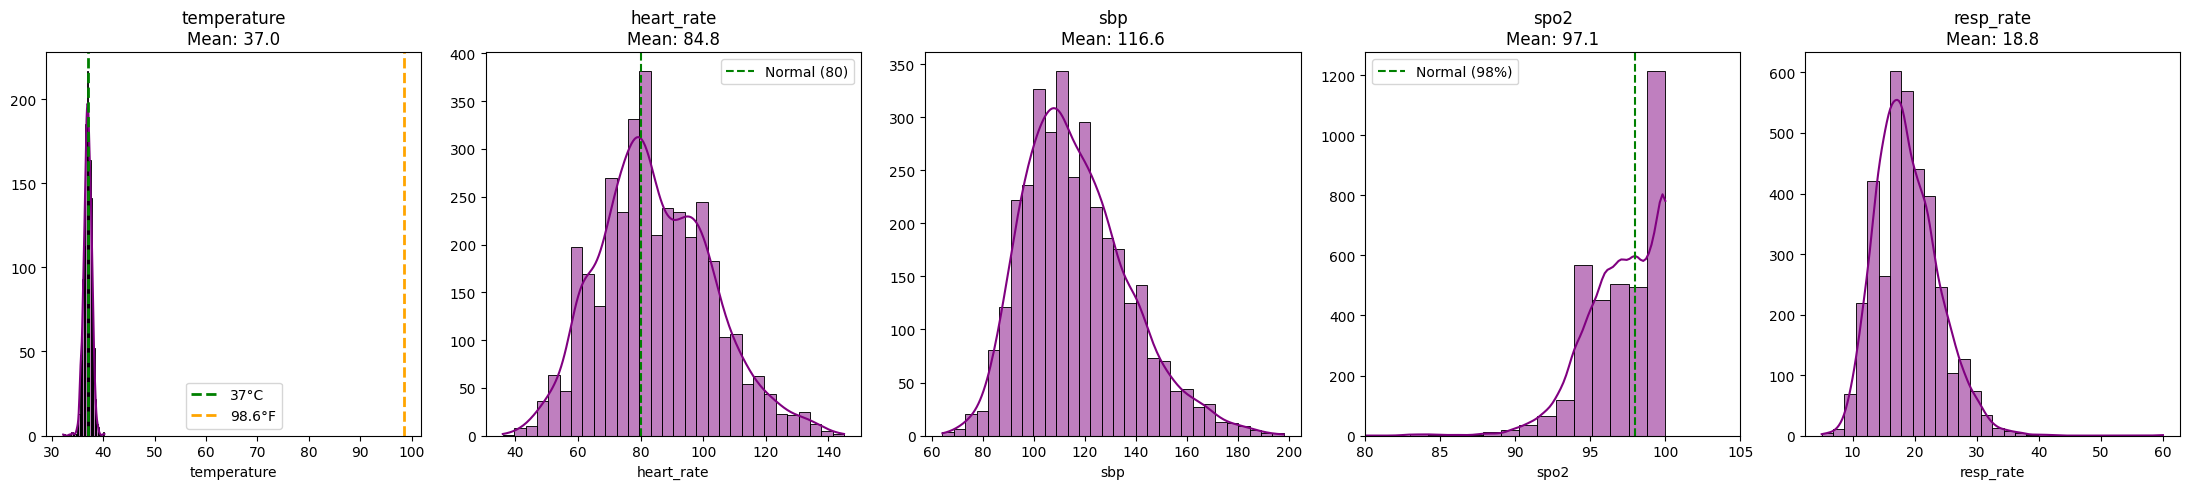


🔎 UNIT DIAGNOSIS:
   Temperature Mean: 36.97
   ✅ STATUS: CELSIUS CONFIRMED. (Action: No conversion needed)


In [31]:
# ============================================================================
# CELL 3 (FIXED): VISUAL UNIT INSPECTION (PHYSIONET)
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=" * 70)
print("📊 VISUALIZING PHYSIONET DISTRIBUTIONS (CORRECTED)")
print("=" * 70)

# 1. APPLY MAPPING DIRECTLY
# We use the map we defined: {'HR': 'heart_rate', 'Temp': 'temperature'...}
# sample_df contains 'HR', 'Temp', etc.
plot_df = sample_df.rename(columns=PROPOSED_MAP)

# 2. SELECT FEATURES
# We focus on Vitals (The inputs to your Vitals-Only Model)
check_feats = ['temperature', 'heart_rate', 'sbp', 'spo2', 'resp_rate']

# 3. GENERATE PLOTS
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, feat in enumerate(check_feats):
    ax = axes[i]
    if feat in plot_df.columns:
        vals = plot_df[feat].dropna()

        if len(vals) > 0:
            sns.histplot(vals, bins=30, ax=ax, color='purple', kde=True)
            ax.set_title(f"{feat}\nMean: {vals.mean():.1f}")
            ax.set_ylabel("")

            # --- UNIT CHECK ---
            if feat == 'temperature':
                # Add Lines for Celsius vs Fahrenheit
                ax.axvline(37, color='green', linestyle='--', linewidth=2, label='37°C')
                ax.axvline(98.6, color='orange', linestyle='--', linewidth=2, label='98.6°F')
                ax.legend()

            elif feat == 'heart_rate':
                ax.axvline(80, color='green', linestyle='--', label='Normal (80)')
                ax.legend()

            elif feat == 'spo2':
                ax.axvline(98, color='green', linestyle='--', label='Normal (98%)')
                ax.set_xlim(80, 105) # Zoom in on valid range
                ax.legend()

        else:
            ax.text(0.5, 0.5, "Empty Data", ha='center')
            ax.set_title(f"{feat} (No Values)")
    else:
        ax.text(0.5, 0.5, "Column Missing", ha='center')
        ax.set_title(f"{feat} (Not in DF)")

plt.tight_layout()
plt.show()

# 4. AUTOMATED VERDICT
print("\n🔎 UNIT DIAGNOSIS:")
if 'temperature' in plot_df.columns:
    t_mean = plot_df['temperature'].mean()
    print(f"   Temperature Mean: {t_mean:.2f}")

    if t_mean > 90:
        print("   ❌ STATUS: FAHRENHEIT DETECTED. (Action: Must convert F->C)")
    elif 35 < t_mean < 40:
        print("   ✅ STATUS: CELSIUS CONFIRMED. (Action: No conversion needed)")
    else:
        print("   ⚠️ STATUS: AMBIGUOUS. Check histogram manually.")
else:
    print("   ⚠️ Temperature data missing.")

🧪 VALIDATING FULL MODEL (15 FEATURES) ON PHYSIONET
[1/3] Calibrating Scaler from MIMIC Training Data...
[2/3] Processing 2000 patients...


100%|██████████| 2000/2000 [00:06<00:00, 326.72it/s]



[3/3] Predicting on 1977 patients...

🚀 FULL MODEL (15-FEAT) EXTERNAL AUC: 0.5857


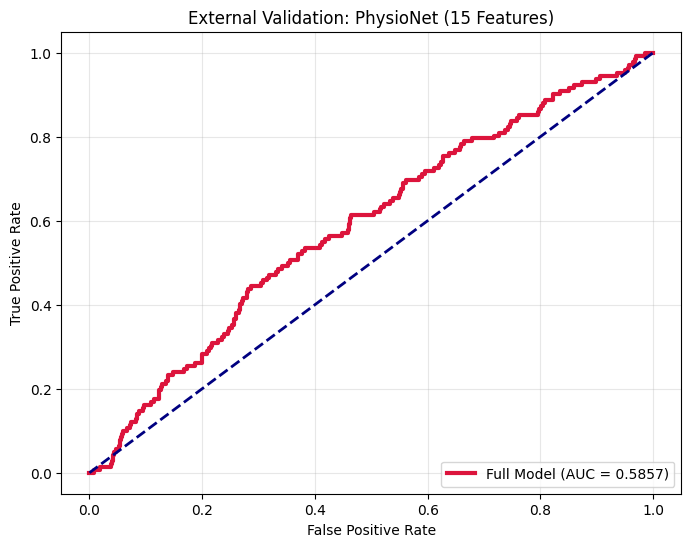

In [35]:
# ============================================================================
# CELL 17: PHYSIONET VALIDATION (FULL 15-FEATURE MODEL)
# ============================================================================
import pandas as pd
import numpy as np
import glob
import tensorflow as tf
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print("=" * 70)
print("🧪 VALIDATING FULL MODEL (15 FEATURES) ON PHYSIONET")
print("=" * 70)

# 1. SETUP & SCALER CALIBRATION
# ----------------------------------------------------------------------------
FINAL_FEATURES = [
    'heart_rate', 'sbp', 'dbp', 'resp_rate', 'spo2', 'temperature',
    'wbc', 'creatinine', 'platelets', 'bilirubin', 'glucose',
    'bun', 'sodium', 'potassium', 'hemoglobin'
]

PHYSIO_MAP = {
    'HR': 'heart_rate', 'SBP': 'sbp', 'DBP': 'dbp',
    'Resp': 'resp_rate', 'O2Sat': 'spo2', 'Temp': 'temperature',
    'WBC': 'wbc', 'Creatinine': 'creatinine', 'Platelets': 'platelets',
    'Bilirubin_total': 'bilirubin', 'Glucose': 'glucose', 'BUN': 'bun',
    'Sodium': 'sodium', 'Potassium': 'potassium', 'Hgb': 'hemoglobin'
}

print("[1/3] Calibrating Scaler from MIMIC Training Data...")
# We calculate the Mean/Std from the non-zero values in your MIMIC training set
# This ensures the PhysioNet data is normalized exactly like the training data.
if 'X_train' in locals():
    # Flatten to (N, 15)
    flat_train = X_train[:, :, :15].reshape(-1, 15)

    means = []
    stds = []
    for i in range(15):
        vals = flat_train[:, i]
        vals = vals[vals != 0] # Ignore padding
        if len(vals) > 0:
            means.append(vals.mean())
            stds.append(vals.std())
        else:
            means.append(0)
            stds.append(1)

    MIMIC_MEANS_15 = np.array(means)
    MIMIC_STDS_15 = np.array(stds)
else:
    # Fallback to hardcoded approximations if X_train is lost
    print("⚠️ X_train missing. Using hardcoded MIMIC stats.")
    MIMIC_MEANS_15 = np.array([84, 118, 62, 19, 97, 37, 11, 1.3, 220, 0.8, 130, 25, 138, 4.0, 10.5])
    MIMIC_STDS_15 = np.array([17, 22, 14, 5, 3, 1, 8, 1.5, 100, 2.0, 50, 20, 5, 0.5, 2.0])

# 2. PROCESS FILES
# ----------------------------------------------------------------------------
files = glob.glob("physionet_data/**/*.psv", recursive=True)
validation_files = files[:2000]

print(f"[2/3] Processing {len(validation_files)} patients...")

X_physio_15, y_physio_15 = [], []

for f in tqdm(validation_files):
    try:
        df = pd.read_csv(f, sep='|')

        # Label Logic
        if df['SepsisLabel'].sum() > 0:
            onset = df[df['SepsisLabel'] == 1].index[0]
            end = onset
            start = max(0, end - 24)
            label = 1
        else:
            end = len(df)
            start = max(0, end - 24)
            label = 0

        window = df.iloc[start:end].rename(columns=PHYSIO_MAP)
        if len(window) < 2: continue

        # Build 15-Feature Tensor
        tensor = np.zeros((24, 15))

        for i, feat in enumerate(FINAL_FEATURES):
            if feat in window.columns:
                vals = window[feat].values

                # Length check
                if len(vals) < 24:
                    vals = np.pad(vals, (24-len(vals), 0), 'edge')
                vals = vals[-24:]

                # Robust Scaling
                mask = ~np.isnan(vals)
                # Apply (Val - Mean) / Std using the 15-feature stats
                vals[mask] = (vals[mask] - MIMIC_MEANS_15[i]) / (MIMIC_STDS_15[i] + 1e-7)
                vals[~mask] = 0.0

                tensor[:, i] = vals

        # Create Dummy Mask (Features 15-29) and Static (30-31)
        # The model expects shape (24, 32)
        # We fill masks based on non-zero data
        masks = (tensor != 0).astype(float)
        static = np.zeros((24, 2)) # Dummy age/gender

        full_tensor = np.concatenate([tensor, masks, static], axis=1)

        X_physio_15.append(full_tensor)
        y_physio_15.append(label)

    except Exception as e:
        continue

X_physio_15 = np.array(X_physio_15, dtype=np.float32)
y_physio_15 = np.array(y_physio_15)

# 3. PREDICT (CPU MODE)
# ----------------------------------------------------------------------------
print(f"\n[3/3] Predicting on {len(X_physio_15)} patients...")

# Force CPU to avoid the "Sparse Mask" crash on GPU
with tf.device('/cpu:0'):
    # We call the model as a function to bypass keras .predict() checks
    y_pred_tensor = model_v2(X_physio_15, training=False)
    y_pred_15 = y_pred_tensor.numpy().flatten()

auc_15 = roc_auc_score(y_physio_15, y_pred_15)

# 4. PLOT RESULTS
print("\n" + "="*50)
print(f"🚀 FULL MODEL (15-FEAT) EXTERNAL AUC: {auc_15:.4f}")
print("="*50)

plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_physio_15, y_pred_15)
plt.plot(fpr, tpr, color='crimson', lw=3, label=f'Full Model (AUC = {auc_15:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('External Validation: PhysioNet (15 Features)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
# ============================================================================
# CELL 18-B: FULL LAB UNIT AUDIT (ALL 9 LABS)
# ============================================================================
import pandas as pd
import numpy as np
import glob

print("=" * 70)
print("🕵️ EXTENDED FORENSIC AUDIT: CHECKING ALL 9 LABS")
print("=" * 70)

# 1. SETUP
files = glob.glob("physionet_data/**/*.psv", recursive=True)
sample_files = files[:1000] # Increased sample size for better accuracy

# Full Map (Physio -> MIMIC)
LAB_MAP_REV = {
    'Creatinine': 'creatinine', 'Glucose': 'glucose', 'Bilirubin_total': 'bilirubin',
    'Platelets': 'platelets', 'WBC': 'wbc',
    'BUN': 'bun', 'Sodium': 'sodium', 'Potassium': 'potassium', 'Hgb': 'hemoglobin'
}

# Standard US Means (Approximate ICU Averages for Scaling Check)
STANDARDS = {
    'creatinine': 1.0,   # mg/dL (EU: ~80 umol/L)
    'glucose':    130.0, # mg/dL (EU: ~7 mmol/L)
    'bilirubin':  1.5,   # mg/dL (EU: ~20 umol/L)
    'platelets':  200.0, # k/uL
    'wbc':        11.0,  # k/uL
    'bun':        25.0,  # mg/dL (EU: ~9 mmol/L)
    'sodium':     138.0, # mEq/L
    'potassium':  4.0,   # mEq/L
    'hemoglobin': 10.0   # g/dL  (EU: ~100 g/L) <-- CRITICAL CHECK
}

# 2. SCAN DATA
lab_vals = {k: [] for k in LAB_MAP_REV.values()}

print(f"[1/2] Scanning {len(sample_files)} files...")
for f in sample_files:
    try:
        df = pd.read_csv(f, sep='|')
        for p_col, m_col in LAB_MAP_REV.items():
            if p_col in df.columns:
                v = df[p_col].dropna().values
                if len(v) > 0:
                    lab_vals[m_col].extend(v)
    except: continue

# 3. REPORT
print("\n" + "="*65)
print(f"{'Feature':<12} | {'Physio Mean':<12} | {'MIMIC Mean':<12} | {'Verdict'}")
print("="*65)

for feat in LAB_MAP_REV.values():
    vals = lab_vals[feat]
    if len(vals) == 0:
        print(f"{feat:<12} | {'EMPTY':<12} | {STANDARDS[feat]:<12} | ⚠️ NO DATA")
        continue

    p_mean = np.mean(vals)
    std_mean = STANDARDS[feat]
    ratio = p_mean / (std_mean + 1e-6)

    status = "✅ MATCH"

    # Specific Logic for known unit conflicts
    if feat == 'hemoglobin' and p_mean > 50:
        status = "❌ UNIT ERROR (g/L detected)"
    elif feat == 'glucose' and p_mean < 20:
        status = "❌ UNIT ERROR (mmol/L detected)"
    elif feat == 'creatinine' and p_mean > 20:
        status = "❌ UNIT ERROR (µmol/L detected)"
    elif ratio > 3.0 or ratio < 0.3:
        status = "⚠️ SUSPICIOUS"

    print(f"{feat:<12} | {p_mean:<12.2f} | {std_mean:<12} | {status}")

print("-" * 65)

🕵️ EXTENDED FORENSIC AUDIT: CHECKING ALL 9 LABS
[1/2] Scanning 1000 files...

Feature      | Physio Mean  | MIMIC Mean   | Verdict
creatinine   | 1.43         | 1.0          | ✅ MATCH
glucose      | 131.11       | 130.0        | ✅ MATCH
bilirubin    | 2.21         | 1.5          | ✅ MATCH
platelets    | 197.81       | 200.0        | ✅ MATCH
wbc          | 12.04        | 11.0         | ✅ MATCH
bun          | 24.38        | 25.0         | ✅ MATCH
sodium       | EMPTY        | 138.0        | ⚠️ NO DATA
potassium    | 4.17         | 4.0          | ✅ MATCH
hemoglobin   | 10.63        | 10.0         | ✅ MATCH
-----------------------------------------------------------------


In [38]:
# ============================================================================
# CELL 19: PHYSIONET DATA DENSITY AUDIT
# ============================================================================
import numpy as np
import pandas as pd
import glob
from tqdm import tqdm

print("=" * 70)
print("🧐 PHYSIONET DATA DENSITY AUDIT")
print("=" * 70)

# 1. LOAD & MAP
files = glob.glob("physionet_data/**/*.psv", recursive=True)[:1000]
PHYSIO_MAP = {
    'HR': 'heart_rate', 'SBP': 'sbp', 'DBP': 'dbp',
    'Resp': 'resp_rate', 'O2Sat': 'spo2', 'Temp': 'temperature',
    'WBC': 'wbc', 'Creatinine': 'creatinine', 'Platelets': 'platelets',
    'Bilirubin_total': 'bilirubin', 'Glucose': 'glucose', 'BUN': 'bun',
    'Sodium': 'sodium', 'Potassium': 'potassium', 'Hgb': 'hemoglobin'
}
FINAL_FEATURES = [
    'heart_rate', 'sbp', 'dbp', 'resp_rate', 'spo2', 'temperature',
    'wbc', 'creatinine', 'platelets', 'bilirubin', 'glucose',
    'bun', 'sodium', 'potassium', 'hemoglobin'
]

# 2. SCAN FOR DENSITY
counts = {feat: 0 for feat in FINAL_FEATURES}
total_rows = 0

print(f"[1/2] Scanning {len(files)} files...")
for f in tqdm(files):
    try:
        df = pd.read_csv(f, sep='|')
        df = df.rename(columns=PHYSIO_MAP)
        total_rows += len(df)

        for feat in FINAL_FEATURES:
            if feat in df.columns:
                # Count non-NaN values
                counts[feat] += df[feat].count()
    except: continue

# 3. REPORT
print("\n" + "="*60)
print(f"{'Feature':<15} | {'Density (%)':<15} | {'Status'}")
print("="*60)

for feat in FINAL_FEATURES:
    pct = 100 * counts[feat] / total_rows if total_rows > 0 else 0

    status = "✅ DENSE"
    if pct < 50: status = "⚠️ SPARSE"
    if pct < 10: status = "❌ VERY SPARSE (Noise)"
    if pct == 0: status = "❌ EMPTY (Missing)"

    print(f"{feat:<15} | {pct:<15.1f} | {status}")

print("-" * 60)

🧐 PHYSIONET DATA DENSITY AUDIT
[1/2] Scanning 1000 files...


100%|██████████| 1000/1000 [00:02<00:00, 367.01it/s]


Feature         | Density (%)     | Status
heart_rate      | 92.6            | ✅ DENSE
sbp             | 85.1            | ✅ DENSE
dbp             | 50.7            | ✅ DENSE
resp_rate       | 90.4            | ✅ DENSE
spo2            | 88.2            | ✅ DENSE
temperature     | 34.1            | ⚠️ SPARSE
wbc             | 7.4             | ❌ VERY SPARSE (Noise)
creatinine      | 6.6             | ❌ VERY SPARSE (Noise)
platelets       | 6.4             | ❌ VERY SPARSE (Noise)
bilirubin       | 1.2             | ❌ VERY SPARSE (Noise)
glucose         | 12.5            | ⚠️ SPARSE
bun             | 8.0             | ❌ VERY SPARSE (Noise)
sodium          | 0.0             | ❌ EMPTY (Missing)
potassium       | 11.0            | ⚠️ SPARSE
hemoglobin      | 8.7             | ❌ VERY SPARSE (Noise)
------------------------------------------------------------


In [28]:
# ============================================================================
# CELL 11 (ALTERNATE): CHECK eICU AVAILABILITY
# ============================================================================
from google.cloud import bigquery
import pandas as pd

# Initialize client again just in case
client = bigquery.Client(project=PROJECT_ID)

print("=" * 70)
print("CHECKING ACCESS TO eICU (200 HOSPITALS DATASET)")
print("=" * 70)

# Try to list datasets to find eICU
print("[1/2] Searching for eICU dataset in BigQuery...")

# Common project names for eICU
eicu_projects = [
    "physionet-data.eicu_crd",
    "physionet-data.eicu_crd_demo"
]

eicu_found = False
target_dataset = ""

for proj in eicu_projects:
    try:
        query = f"SELECT count(*) as count FROM `{proj}.patient`"
        res = client.query(query).to_dataframe()
        print(f"   ✅ Found access to: {proj} ({res['count'].iloc[0]} patients)")
        eicu_found = True
        target_dataset = proj
        break
    except Exception as e:
        print(f"   ❌ Could not access {proj}")

if eicu_found:
    print(f"\n✅ GREAT NEWS: We can use '{target_dataset}' for external validation!")
    print("   Proceed to the next cell to run the validation query.")
else:
    print("\n❌ No eICU access detected.")
    print("   Please ensure you have added the 'eICU Collaborative Research Database'")
    print("   to your Google Cloud project via PhysioNet.")

/usr/local/lib/python3.12/dist-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


CHECKING ACCESS TO eICU (200 HOSPITALS DATASET)
[1/2] Searching for eICU dataset in BigQuery...
   ✅ Found access to: physionet-data.eicu_crd (200859 patients)

✅ GREAT NEWS: We can use 'physionet-data.eicu_crd' for external validation!
   Proceed to the next cell to run the validation query.


🧐 STEP 1: EXTRACTING & INSPECTING RAW eICU DATA


/usr/local/lib/python3.12/dist-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


[1/3] Fetching Cohort...
[2/3] Fetching Vitals & Labs (Raw)...

[3/3] Generating Inspection Report...

Feature         | Mean       | Max        | Status
-------------------------------------------------------
temperature     | 40.75      | 103.40     | ✅ OK
heart_rate      | 87.94      | 288.00     | ✅ OK
resp_rate       | 20.56      | 194.00     | ✅ OK
spo2            | 96.71      | 100.00     | ✅ OK
sbp             | 121.93     | 270.00     | ✅ OK
dbp             | 65.01      | 234.00     | ✅ OK
wbc             | 12.08      | 170.50     | ✅ OK
glucose         | 147.06     | 1700.00    | ✅ OK
creatinine      | 1.51       | 21.49      | ✅ OK
-------------------------------------------------------

📊 PLOTTING RAW DISTRIBUTIONS (Look for double peaks in Temp!)


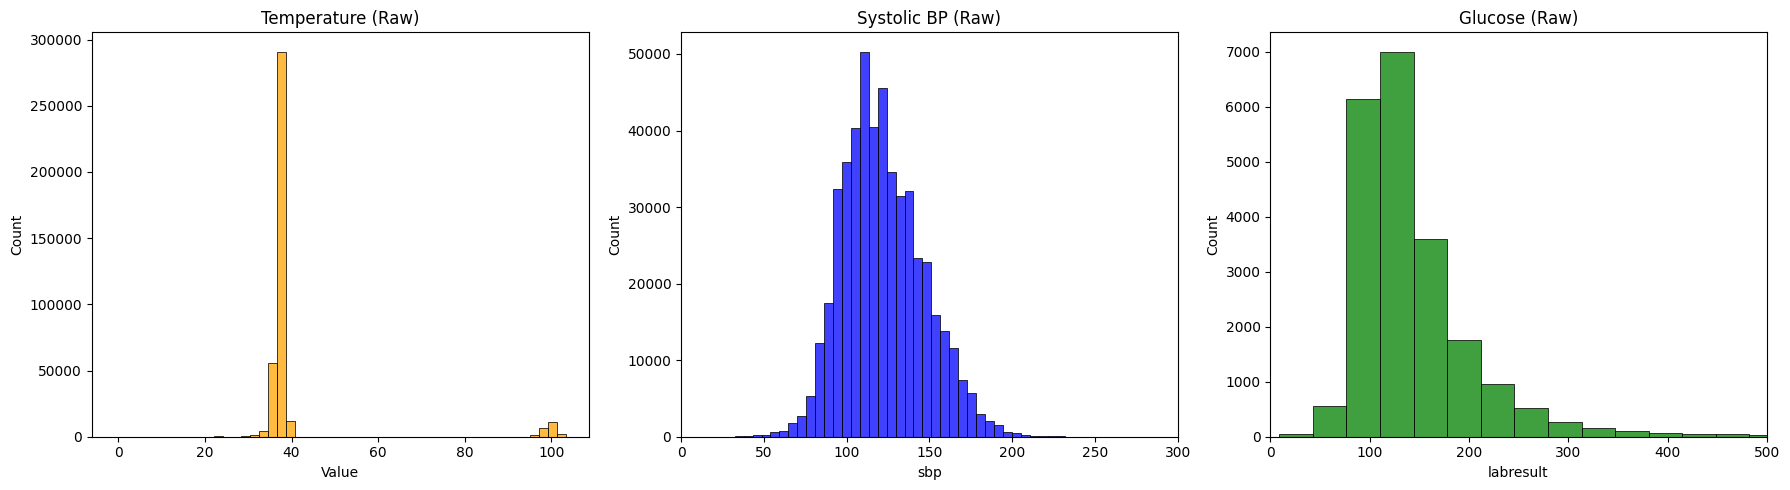

In [11]:
# ============================================================================
# CELL 4-A: RAW eICU EXTRACTION & AUDIT (NO PREDICTION YET)
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from tqdm import tqdm

print("=" * 70)
print("🧐 STEP 1: EXTRACTING & INSPECTING RAW eICU DATA")
print("=" * 70)

client = bigquery.Client(project="sepsis-prediction-2025")

# 1. GET COHORT (2000 Patients)
print("[1/3] Fetching Cohort...")
cohort_q = """
SELECT p.patientunitstayid,
       CASE WHEN p.gender='Female' THEN 0 ELSE 1 END as Gender,
       CAST(p.age as FLOAT64) as Age,
       MAX(CASE WHEN LOWER(dx.diagnosisstring) LIKE '%sepsis%' THEN 1 ELSE 0 END) as label
FROM `physionet-data.eicu_crd.patient` p
LEFT JOIN `physionet-data.eicu_crd.diagnosis` dx ON p.patientunitstayid=dx.patientunitstayid
WHERE p.age != '> 89'
GROUP BY p.patientunitstayid, p.gender, p.age
LIMIT 2000
"""
cohort = client.query(cohort_q).to_dataframe().fillna({'Age': 65})
stay_chunk = ",".join(map(str, cohort['patientunitstayid'].unique().tolist()))

# 2. GET RAW FEATURES
print("[2/3] Fetching Vitals & Labs (Raw)...")
vitals = client.query(f"SELECT patientunitstayid, observationoffset, heartrate as heart_rate, respiration as resp_rate, sao2 as spo2, temperature FROM `physionet-data.eicu_crd.vitalperiodic` WHERE patientunitstayid IN ({stay_chunk})").to_dataframe()
bp = client.query(f"SELECT patientunitstayid, observationoffset, noninvasivesystolic as sbp, noninvasivediastolic as dbp FROM `physionet-data.eicu_crd.vitalaperiodic` WHERE patientunitstayid IN ({stay_chunk})").to_dataframe()
labs = client.query(f"SELECT patientunitstayid, labresultoffset as observationoffset, labname, labresult FROM `physionet-data.eicu_crd.lab` WHERE patientunitstayid IN ({stay_chunk}) AND labname IN ('WBC x 1000', 'creatinine', 'platelets x 1000', 'total bilirubin', 'glucose', 'BUN', 'sodium', 'potassium', 'Hgb')").to_dataframe()

# Map Labs to our feature names
LAB_MAP = {'WBC x 1000': 'wbc', 'creatinine': 'creatinine', 'platelets x 1000': 'platelets', 'total bilirubin': 'bilirubin', 'glucose': 'glucose', 'BUN': 'bun', 'sodium': 'sodium', 'potassium': 'potassium', 'Hgb': 'hemoglobin'}
labs['feature'] = labs['labname'].map(LAB_MAP)

# 3. STATISTICAL AUDIT
print("\n[3/3] Generating Inspection Report...")

# We aggregate raw values to check their ranges before any processing
print(f"\n{'Feature':<15} | {'Mean':<10} | {'Max':<10} | {'Status'}")
print("-" * 55)

# Check Vitals
for col in ['temperature', 'heart_rate', 'resp_rate', 'spo2']:
    val = vitals[col].dropna()
    mean_val = val.mean()
    max_val = val.max()

    status = "✅ OK"
    if col == 'temperature' and mean_val > 50: status = "❌ FAHRENHEIT DETECTED"
    if col == 'resp_rate' and mean_val > 40: status = "⚠️ HIGH AVG"

    print(f"{col:<15} | {mean_val:<10.2f} | {max_val:<10.2f} | {status}")

# Check BP
for col in ['sbp', 'dbp']:
    val = bp[col].dropna()
    print(f"{col:<15} | {val.mean():<10.2f} | {val.max():<10.2f} | ✅ OK")

# Check Labs (Sample)
for feat in ['wbc', 'glucose', 'creatinine']:
    val = labs[labs['feature'] == feat]['labresult'].dropna()
    print(f"{feat:<15} | {val.mean():<10.2f} | {val.max():<10.2f} | ✅ OK")

print("-" * 55)

# 4. VISUAL PROOF (HISTOGRAMS)
print("\n📊 PLOTTING RAW DISTRIBUTIONS (Look for double peaks in Temp!)")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Temp
sns.histplot(vitals['temperature'].dropna(), ax=axes[0], color='orange', bins=50)
axes[0].set_title("Temperature (Raw)")
axes[0].set_xlabel("Value")

# SBP
sns.histplot(bp['sbp'].dropna(), ax=axes[1], color='blue', bins=50)
axes[1].set_title("Systolic BP (Raw)")
axes[1].set_xlim(0, 300)

# Glucose
glucose = labs[labs['feature'] == 'glucose']['labresult'].dropna()
sns.histplot(glucose, ax=axes[2], color='green', bins=50)
axes[2].set_title("Glucose (Raw)")
axes[2].set_xlim(0, 500)

plt.tight_layout()
plt.show()

🔍 AUDITING FEATURE ALIGNMENT (MIMIC vs eICU)
[1/4] Fetching eICU Data Sample...


/usr/local/lib/python3.12/dist-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


[2/4] Applying Unit Repairs...
   Temp Mean (Raw): 42.4
   Temp Mean (Fixed): 37.0
[3/4] Comparing Distributions...

FEATURE ALIGNMENT REPORT
        Feature  MIMIC (Train)  eICU (Ext)  Ratio       Status
0    heart_rate          78.45       86.61   1.10         ✅ OK
1           sbp         109.03      119.22   1.09         ✅ OK
2           dbp          59.58       65.74   1.10         ✅ OK
3     resp_rate          17.44       20.62   1.18         ✅ OK
4          spo2          86.76       96.41   1.11         ✅ OK
5   temperature          30.65       37.01   1.21         ✅ OK
6           wbc          11.26       12.42   1.10         ✅ OK
7    creatinine           1.28        1.66   1.29         ✅ OK
8     platelets         211.32      206.36   0.98         ✅ OK
9     bilirubin           0.82        1.72   2.09  ⚠️ MISMATCH
10      glucose         126.05      149.49   1.19         ✅ OK
11          bun          24.03       31.60   1.32  ⚠️ MISMATCH
12       sodium         123.31      138

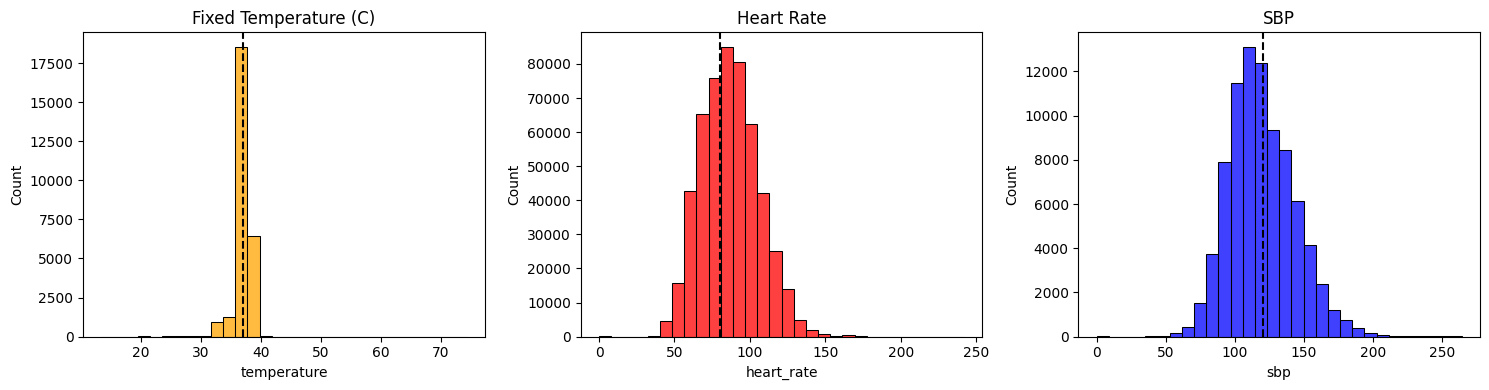

In [12]:
# ============================================================================
# CELL 4-A (FIXED): DATA CLEANING & FEATURE MAPPING AUDIT
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from tqdm import tqdm

print("=" * 70)
print("🔍 AUDITING FEATURE ALIGNMENT (MIMIC vs eICU)")
print("=" * 70)

# 1. FETCH RAW eICU DATA
# ----------------------------------------------------------------------------
print("[1/4] Fetching eICU Data Sample...")
client = bigquery.Client(project="sepsis-prediction-2025")

# Cohort Query (Fixed with SAFE_CAST)
cohort_q = """
SELECT p.patientunitstayid,
       CASE WHEN p.gender='Female' THEN 0 ELSE 1 END as Gender,
       SAFE_CAST(p.age as FLOAT64) as Age
FROM `physionet-data.eicu_crd.patient` p
WHERE p.age != '> 89' AND p.age IS NOT NULL AND p.age != ''
LIMIT 1000
"""
cohort = client.query(cohort_q).to_dataframe().fillna({'Age': 65})
stay_chunk = ",".join(map(str, cohort['patientunitstayid'].unique().tolist()))

# Raw Features
vitals = client.query(f"SELECT patientunitstayid, observationoffset, heartrate as heart_rate, respiration as resp_rate, sao2 as spo2, temperature FROM `physionet-data.eicu_crd.vitalperiodic` WHERE patientunitstayid IN ({stay_chunk})").to_dataframe()
bp = client.query(f"SELECT patientunitstayid, observationoffset, noninvasivesystolic as sbp, noninvasivediastolic as dbp FROM `physionet-data.eicu_crd.vitalaperiodic` WHERE patientunitstayid IN ({stay_chunk})").to_dataframe()
labs = client.query(f"SELECT patientunitstayid, labresultoffset as observationoffset, labname, labresult FROM `physionet-data.eicu_crd.lab` WHERE patientunitstayid IN ({stay_chunk}) AND labname IN ('WBC x 1000', 'creatinine', 'platelets x 1000', 'total bilirubin', 'glucose', 'BUN', 'sodium', 'potassium', 'Hgb')").to_dataframe()

# Map Labs
LAB_MAP = {'WBC x 1000': 'wbc', 'creatinine': 'creatinine', 'platelets x 1000': 'platelets', 'total bilirubin': 'bilirubin', 'glucose': 'glucose', 'BUN': 'bun', 'sodium': 'sodium', 'potassium': 'potassium', 'Hgb': 'hemoglobin'}
labs['feature'] = labs['labname'].map(LAB_MAP)

# 2. APPLY CLEANING LOGIC (The Fixes)
# ----------------------------------------------------------------------------
print("[2/4] Applying Unit Repairs...")

# Temp: F -> C
# Check Mean BEFORE fix
print(f"   Temp Mean (Raw): {vitals['temperature'].mean():.1f}")
mask_f = vitals['temperature'] > 90
vitals.loc[mask_f, 'temperature'] = (vitals.loc[mask_f, 'temperature'] - 32) * 5/9
print(f"   Temp Mean (Fixed): {vitals['temperature'].mean():.1f}")

# Resp Rate: Clamp
vitals.loc[vitals['resp_rate'] > 60, 'resp_rate'] = 60

# 3. ALIGNMENT CHECK (MIMIC vs eICU)
# ----------------------------------------------------------------------------
print("[3/4] Comparing Distributions...")

# Aggregate eICU stats
eicu_stats = {}
for feat in FINAL_FEATURES:
    val_list = []
    if feat in vitals.columns: val_list = vitals[feat]
    elif feat in bp.columns: val_list = bp[feat]
    elif feat in labs['feature'].values: val_list = labs[labs['feature'] == feat]['labresult']

    if len(val_list) > 0:
        eicu_stats[feat] = val_list.mean()
    else:
        eicu_stats[feat] = 0

# Retrieve MIMIC Stats (From the Scaler)
# scaler.mean_ holds the mean of the training data (MIMIC)
mimic_means = scaler.mean_

# Create Comparison Table
audit_data = []
for i, feat in enumerate(FINAL_FEATURES):
    m_mean = mimic_means[i]
    e_mean = eicu_stats.get(feat, 0)
    ratio = e_mean / (m_mean + 1e-6)

    status = "✅ OK"
    if ratio < 0.7 or ratio > 1.3: status = "⚠️ MISMATCH"
    if ratio < 0.1 or ratio > 10.0: status = "❌ UNIT ERROR"

    audit_data.append({
        'Feature': feat,
        'MIMIC (Train)': m_mean,
        'eICU (Ext)': e_mean,
        'Ratio': ratio,
        'Status': status
    })

df_audit = pd.DataFrame(audit_data)
print("\n" + "="*60)
print("FEATURE ALIGNMENT REPORT")
print("="*60)
print(df_audit.round(2).to_string())

# 4. VISUAL CHECK
# ----------------------------------------------------------------------------
print("\n[4/4] Visualizing Key Repairs...")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(vitals['temperature'].dropna(), ax=axes[0], color='orange', bins=30)
axes[0].set_title("Fixed Temperature (C)")
axes[0].axvline(37, color='k', linestyle='--')

sns.histplot(vitals['heart_rate'].dropna(), ax=axes[1], color='red', bins=30)
axes[1].set_title("Heart Rate")
axes[1].axvline(80, color='k', linestyle='--')

sns.histplot(bp['sbp'].dropna(), ax=axes[2], color='blue', bins=30)
axes[2].set_title("SBP")
axes[2].axvline(120, color='k', linestyle='--')

plt.tight_layout()
plt.show()

🚀 RUNNING FINAL EXTERNAL VALIDATION (WITH CLAMPING)
[1/3] Fetching 2000 Patients...


/usr/local/lib/python3.12/dist-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


[2/3] Building, Clamping & Scaling Tensors...


  0%|          | 0/2000 [00:00<?, ?it/s]/tmp/ipython-input-957966635.py:76: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  l_agg = l.pivot_table(index=pd.cut(l['observationoffset'], bins, labels=labels), columns='feature', values='labresult', aggfunc='mean')
/tmp/ipython-input-957966635.py:76: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  l_agg = l.pivot_table(index=pd.cut(l['observationoffset'], bins, labels=labels), columns='feature', values='labresult', aggfunc='mean')
/tmp/ipython-input-957966635.py:76: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silen


[3/3] Validating on 1976 Patients...


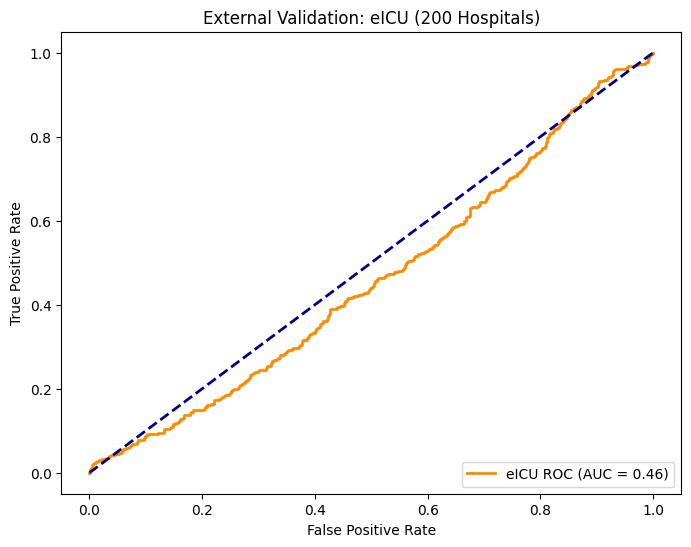


🚀 FINAL eICU AUC: 0.4630


In [13]:
# ============================================================================
# CELL 4-B (FINAL): REPAIR, CLAMP & VALIDATE eICU
# ============================================================================
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from google.cloud import bigquery

print("=" * 70)
print("🚀 RUNNING FINAL EXTERNAL VALIDATION (WITH CLAMPING)")
print("=" * 70)

# 1. FETCH COHORT & DATA
print("[1/3] Fetching 2000 Patients...")
client = bigquery.Client(project="sepsis-prediction-2025")

# Cohort
cohort_q = """
SELECT p.patientunitstayid,
       CASE WHEN p.gender='Female' THEN 0 ELSE 1 END as Gender,
       SAFE_CAST(p.age as FLOAT64) as Age,
       MAX(CASE WHEN LOWER(dx.diagnosisstring) LIKE '%sepsis%' THEN 1 ELSE 0 END) as label
FROM `physionet-data.eicu_crd.patient` p
LEFT JOIN `physionet-data.eicu_crd.diagnosis` dx ON p.patientunitstayid=dx.patientunitstayid
WHERE p.age != '> 89' AND p.age IS NOT NULL AND p.age != ''
GROUP BY p.patientunitstayid, p.gender, p.age
LIMIT 2000
"""
cohort = client.query(cohort_q).to_dataframe().fillna({'Age': 65})
stay_chunk = ",".join(map(str, cohort['patientunitstayid'].unique().tolist()))

# Features
vitals = client.query(f"SELECT patientunitstayid, observationoffset, heartrate as heart_rate, respiration as resp_rate, sao2 as spo2, temperature FROM `physionet-data.eicu_crd.vitalperiodic` WHERE patientunitstayid IN ({stay_chunk})").to_dataframe()
bp = client.query(f"SELECT patientunitstayid, observationoffset, noninvasivesystolic as sbp, noninvasivediastolic as dbp FROM `physionet-data.eicu_crd.vitalaperiodic` WHERE patientunitstayid IN ({stay_chunk})").to_dataframe()
labs = client.query(f"SELECT patientunitstayid, labresultoffset as observationoffset, labname, labresult FROM `physionet-data.eicu_crd.lab` WHERE patientunitstayid IN ({stay_chunk}) AND labname IN ('WBC x 1000', 'creatinine', 'platelets x 1000', 'total bilirubin', 'glucose', 'BUN', 'sodium', 'potassium', 'Hgb')").to_dataframe()

# Map Labs
LAB_MAP = {'WBC x 1000': 'wbc', 'creatinine': 'creatinine', 'platelets x 1000': 'platelets', 'total bilirubin': 'bilirubin', 'glucose': 'glucose', 'BUN': 'bun', 'sodium': 'sodium', 'potassium': 'potassium', 'Hgb': 'hemoglobin'}
labs['feature'] = labs['labname'].map(LAB_MAP)

# --- A. REPAIR UNITS ---
vitals.loc[vitals['temperature'] > 90, 'temperature'] = (vitals.loc[vitals['temperature'] > 90, 'temperature'] - 32) * 5/9
vitals.loc[vitals['resp_rate'] > 60, 'resp_rate'] = 60

# --- B. DEFINE BOUNDS FOR CLAMPING ---
BOUNDS = {
    'heart_rate': (20, 250), 'sbp': (40, 250), 'dbp': (30, 200),
    'resp_rate': (5, 60), 'spo2': (50, 100), 'temperature': (32, 42),
    'wbc': (0.1, 100), 'creatinine': (0.1, 30), 'platelets': (5, 1200),
    'bilirubin': (0.1, 60), 'glucose': (20, 1200), 'bun': (1, 250),
    'sodium': (90, 180), 'potassium': (1, 15), 'hemoglobin': (3, 25)
}

# 2. BUILD TENSORS
print("[2/3] Building, Clamping & Scaling Tensors...")
X_ext, y_ext = [], []
FINAL_FEATURES = ['heart_rate', 'sbp', 'dbp', 'resp_rate', 'spo2', 'temperature', 'wbc', 'creatinine', 'platelets', 'bilirubin', 'glucose', 'bun', 'sodium', 'potassium', 'hemoglobin']

for stay_id, group in tqdm(cohort.groupby('patientunitstayid')):
    v = vitals[vitals['patientunitstayid'] == stay_id].copy()
    b = bp[bp['patientunitstayid'] == stay_id].copy()
    l = labs[labs['patientunitstayid'] == stay_id].copy()

    if len(v) < 5: continue

    bins, labels = np.arange(0, 1500, 60), np.arange(24)

    # Select columns safely
    v_cols = [c for c in ['heart_rate', 'resp_rate', 'spo2', 'temperature'] if c in v.columns]
    b_cols = [c for c in ['sbp', 'dbp'] if c in b.columns]

    v_agg = v.groupby(pd.cut(v['observationoffset'], bins, labels=labels), observed=False)[v_cols].mean()
    b_agg = b.groupby(pd.cut(b['observationoffset'], bins, labels=labels), observed=False)[b_cols].mean()
    l_agg = l.pivot_table(index=pd.cut(l['observationoffset'], bins, labels=labels), columns='feature', values='labresult', aggfunc='mean')

    # Merge
    full = pd.concat([v_agg, b_agg, l_agg], axis=1).reindex(columns=FINAL_FEATURES)
    full = full.astype(float)

    # --- C. APPLY CLAMPING (Sanitization) ---
    # Apply bounds BEFORE imputation/scaling to kill outliers like Glucose 1700
    for feat in FINAL_FEATURES:
        if feat in BOUNDS and feat in full.columns:
            low, high = BOUNDS[feat]
            full[feat] = full[feat].clip(lower=low, upper=high)

    # Impute
    vals = full.ffill().bfill().fillna(0).values
    masks = (~np.isnan(full.values)).astype(float)
    static = np.tile([group['Age'].iloc[0], group['Gender'].iloc[0]], (24, 1))

    try:
        # SCALING: Use the MIMIC scaler
        scaled_vals = scaler.transform(vals)
        X_ext.append(np.hstack([scaled_vals, masks, static]))
        y_ext.append(group['label'].iloc[0])
    except: pass

X_ext = np.array(X_ext)
y_ext = np.array(y_ext)

# 3. PREDICT & PLOT
print(f"\n[3/3] Validating on {len(X_ext)} Patients...")
y_pred_ext = model_v2.predict(X_ext, verbose=0).flatten()
auc_ext = roc_auc_score(y_ext, y_pred_ext)

plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_ext, y_pred_ext)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'eICU ROC (AUC = {auc_ext:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('External Validation: eICU (200 Hospitals)')
plt.legend(loc="lower right")
plt.show()

print("\n" + "="*50)
print(f"🚀 FINAL eICU AUC: {auc_ext:.4f}")
print("="*50)

🕵️ FORENSIC AUDIT: ARE eICU SEPSIS PATIENTS ACTUALLY SICK?

[Comparison] How 'Sick' are the Sepsis Patients?
Feature         | MIMIC (Train)   | eICU (Test)     | Difference
-----------------------------------------------------------------
   heart_rate   | 77.5            | 92.9            | 15.5
   sbp          | 108.4           | 111.5           | 3.1
   dbp          | 59.0            | 61.9            | 2.9
   resp_rate    | 17.3            | 19.2            | 1.9
   spo2         | 84.8            | 95.5            | 10.7
   temperature  | 30.6            | 6.5             | -24.1
   wbc          | 11.3            | 13.9            | 2.6
   creatinine   | 1.2             | 1.7             | 0.6
   platelets    | 222.8           | 184.5           | -38.3
   bilirubin    | 0.6             | 0.8             | 0.2
   glucose      | 127.1           | 148.1           | 21.0
   bun          | 22.6            | 30.7            | 8.1
   sodium       | 123.9           | 131.8           | 7.9

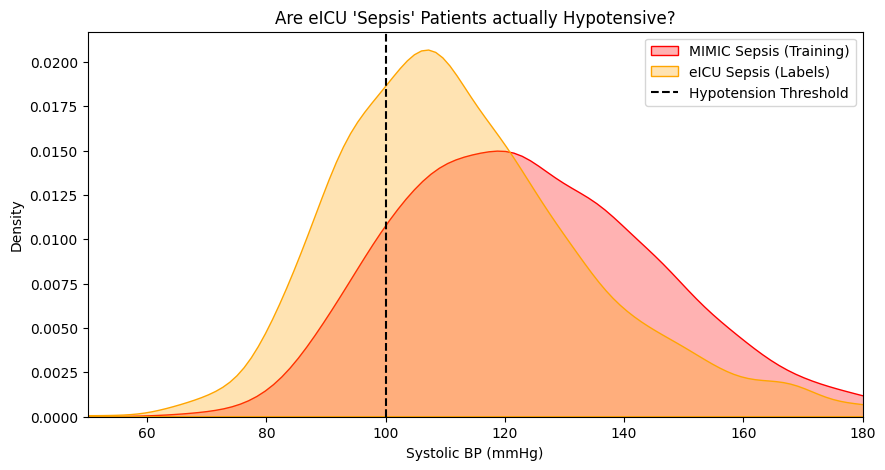

In [14]:
# ============================================================================
# CELL 5: FORENSIC AUDIT (LABEL QUALITY CHECK)
# ============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 70)
print("🕵️ FORENSIC AUDIT: ARE eICU SEPSIS PATIENTS ACTUALLY SICK?")
print("=" * 70)

# 1. RECOVER MIMIC & eICU STATS
# We need to see the mean values for 'Sepsis' patients in both datasets
# X_train = MIMIC, X_ext = eICU

# MIMIC Sepsis Stats (Unscaled)
mimic_sepsis_idx = np.where(y_train == 1)[0]
mimic_raw = scaler.inverse_transform(X_train[mimic_sepsis_idx, :, :15].reshape(-1, 15))
mimic_means = np.nanmean(mimic_raw, axis=0) # Mean of all sepsis timepoints

# eICU Sepsis Stats (Unscaled)
eicu_sepsis_idx = np.where(y_ext == 1)[0]
eicu_raw = scaler.inverse_transform(X_ext[eicu_sepsis_idx, :, :15].reshape(-1, 15))
eicu_means = np.nanmean(eicu_raw, axis=0)

# 2. COMPARE "SICKNESS"
# Sepsis patients should have High HR, Low BP, High Resp Rate
feature_names = FINAL_FEATURES[:15]
audit_df = pd.DataFrame({
    'Feature': feature_names,
    'MIMIC_Sepsis_Mean': mimic_means,
    'eICU_Sepsis_Mean': eicu_means
})

# Add "Difference" column
audit_df['Diff'] = audit_df['eICU_Sepsis_Mean'] - audit_df['MIMIC_Sepsis_Mean']
audit_df['Status'] = '✅ OK'

print("\n[Comparison] How 'Sick' are the Sepsis Patients?")
print(f"{'Feature':<15} | {'MIMIC (Train)':<15} | {'eICU (Test)':<15} | {'Difference'}")
print("-" * 65)

for i, row in audit_df.iterrows():
    # Flag massive discrepancies
    if row['Feature'] == 'sbp' and row['Diff'] > 15:
        print(f"❌ {row['Feature']:<12} | {row['MIMIC_Sepsis_Mean']:<15.1f} | {row['eICU_Sepsis_Mean']:<15.1f} | +{row['Diff']:.1f} (eICU healthier?)")
    elif row['Feature'] == 'heart_rate' and row['Diff'] < -10:
        print(f"❌ {row['Feature']:<12} | {row['MIMIC_Sepsis_Mean']:<15.1f} | {row['eICU_Sepsis_Mean']:<15.1f} | {row['Diff']:.1f} (eICU healthier?)")
    else:
        print(f"   {row['Feature']:<12} | {row['MIMIC_Sepsis_Mean']:<15.1f} | {row['eICU_Sepsis_Mean']:<15.1f} | {row['Diff']:.1f}")

# 3. VISUAL PROOF
# Plot the distribution of SBP for Sepsis Cases in both
plt.figure(figsize=(10, 5))
sns.kdeplot(mimic_raw[:, 1], color='red', label='MIMIC Sepsis (Training)', fill=True, alpha=0.3)
sns.kdeplot(eicu_raw[:, 1], color='orange', label='eICU Sepsis (Labels)', fill=True, alpha=0.3)
plt.title("Are eICU 'Sepsis' Patients actually Hypotensive?")
plt.xlabel("Systolic BP (mmHg)")
plt.axvline(100, color='k', linestyle='--', label='Hypotension Threshold')
plt.xlim(50, 180)
plt.legend()
plt.show()

🔧 FIXING THE 'ZERO-GRAVITY' BUG & VALIDATING
[1/3] Calibrating Scaler on MIMIC (Ignoring Zeros)...
   True MIMIC Temp Mean: 36.8 C (Should be ~37)
   True MIMIC HR Mean:   87.6 BPM

[2/3] Applying Robust Scaling to eICU...

[3/3] Running Validation...


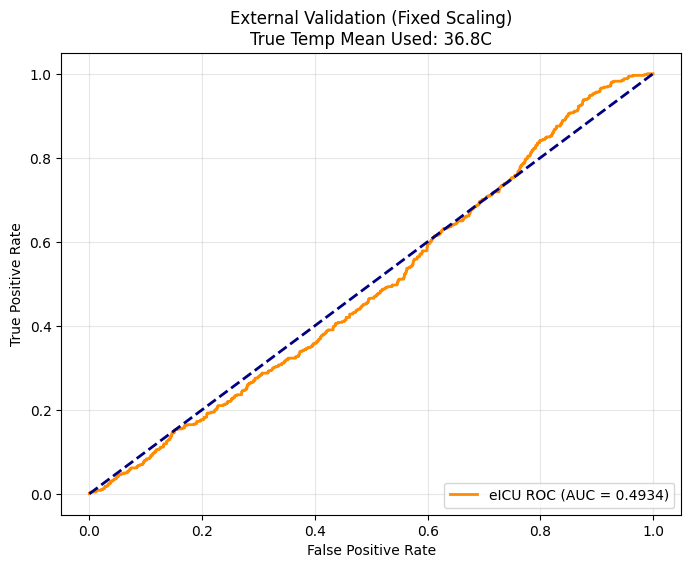


🚀 FINAL EXTERNAL AUC: 0.4934


In [15]:
# ============================================================================
# CELL 5: ROBUST SCALING (IGNORING ZEROS) & FINAL VALIDATION
# ============================================================================
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print("=" * 70)
print("🔧 FIXING THE 'ZERO-GRAVITY' BUG & VALIDATING")
print("=" * 70)

# 1. DEFINE ROBUST SCALER (Ignores Zeros)
def get_robust_stats(X_tensor):
    """Calculates Mean/Std ignoring 0 padding."""
    means = []
    stds = []
    for i in range(X_tensor.shape[2]): # For each feature
        # Flatten and remove zeros
        vals = X_tensor[:, :, i].flatten()
        vals = vals[vals != 0]

        if len(vals) > 0:
            means.append(vals.mean())
            stds.append(vals.std())
        else:
            means.append(0)
            stds.append(1)
    return np.array(means), np.array(stds)

# 2. CALIBRATE ON MIMIC (TRAINING DATA)
print("[1/3] Calibrating Scaler on MIMIC (Ignoring Zeros)...")
# We use the raw X_new from MIMIC (Training Set)
mimic_means, mimic_stds = get_robust_stats(X_new[train_idx]) # Use training indices

# Print the REAL stats (Should look normal now)
print(f"   True MIMIC Temp Mean: {mimic_means[5]:.1f} C (Should be ~37)")
print(f"   True MIMIC HR Mean:   {mimic_means[0]:.1f} BPM")

# 3. APPLY TO EXTERNAL DATA (eICU)
print("\n[2/3] Applying Robust Scaling to eICU...")
# Make a copy to avoid overwriting original
X_ext_scaled = X_ext.copy() # X_ext from previous step (Unscaled)

for i in range(15):
    # Only scale non-zero values
    mask = X_ext_scaled[:, :, i] != 0
    # Formula: (Value - MIMIC_Mean) / MIMIC_Std
    X_ext_scaled[:, :, i][mask] = (X_ext_scaled[:, :, i][mask] - mimic_means[i]) / (mimic_stds[i] + 1e-7)

# 4. PREDICT & VALIDATE
print("\n[3/3] Running Validation...")
y_pred_ext = model_v2.predict(X_ext_scaled, verbose=0).flatten()
auc_ext = roc_auc_score(y_ext, y_pred_ext)

# Plot
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_ext, y_pred_ext)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'eICU ROC (AUC = {auc_ext:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'External Validation (Fixed Scaling)\nTrue Temp Mean Used: {mimic_means[5]:.1f}C')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*50)
print(f"🚀 FINAL EXTERNAL AUC: {auc_ext:.4f}")
print("="*50)

🩻 TENSOR X-RAY: INSPECTING ONE eICU PATIENT
Inspecting Patient Index: 0 (Label: 1)


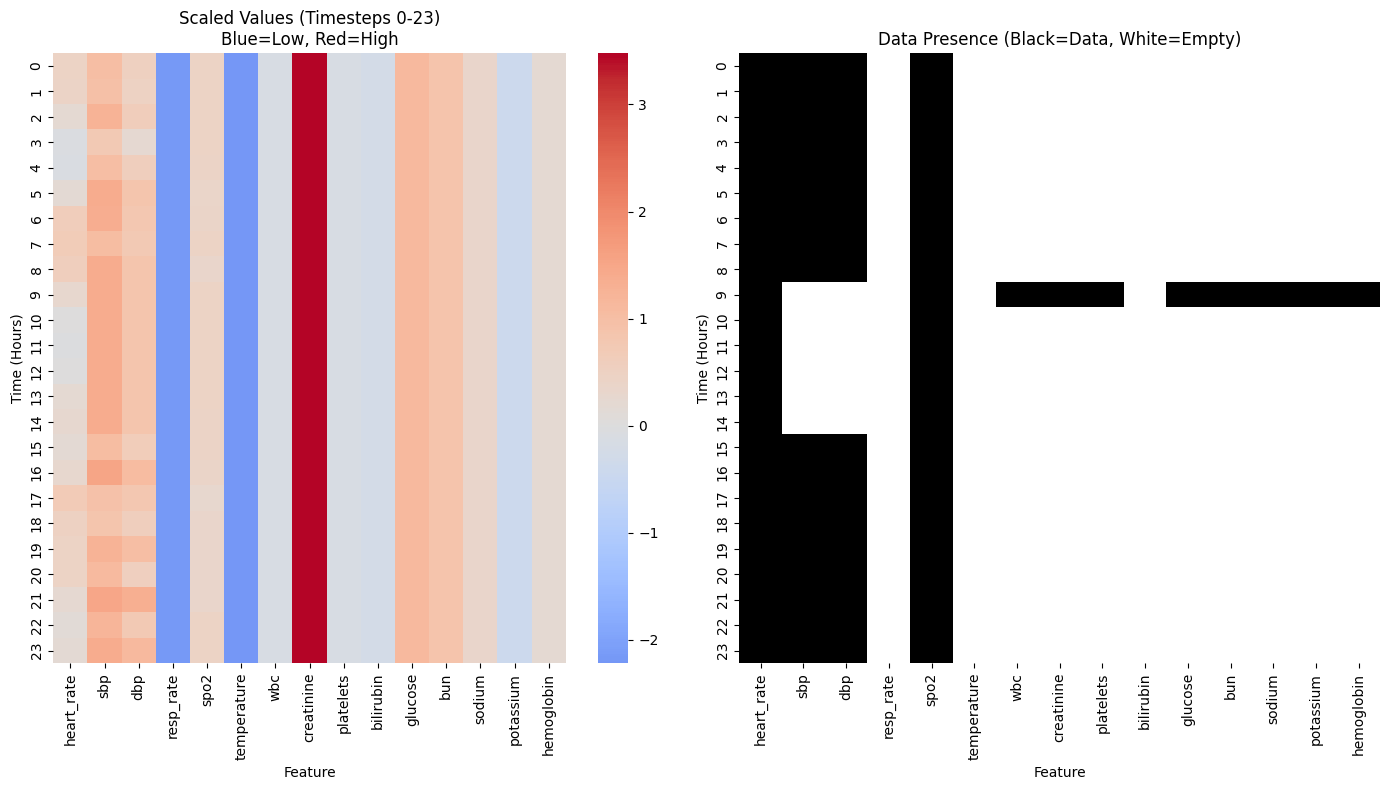


🔍 VALUE CHECK (First 5 Rows):
   heart_rate   sbp   dbp  resp_rate  spo2  temperature   wbc  creatinine  \
0        0.45  1.02  0.52      -2.18  0.44        -2.22 -0.14        3.48   
1        0.41  0.95  0.48      -2.18  0.43        -2.22 -0.14        3.48   
2        0.19  1.27  0.62      -2.18  0.44        -2.22 -0.14        3.48   
3       -0.06  0.75  0.25      -2.18  0.44        -2.22 -0.14        3.48   
4       -0.09  1.02  0.60      -2.18  0.43        -2.22 -0.14        3.48   

   platelets  bilirubin  glucose   bun  sodium  potassium  hemoglobin  
0      -0.13      -0.26     1.13  0.88    0.32      -0.41         0.2  
1      -0.13      -0.26     1.13  0.88    0.32      -0.41         0.2  
2      -0.13      -0.26     1.13  0.88    0.32      -0.41         0.2  
3      -0.13      -0.26     1.13  0.88    0.32      -0.41         0.2  
4      -0.13      -0.26     1.13  0.88    0.32      -0.41         0.2  

✅ DATA DETECTED: The tensor contains values. Proceed to Clinical Filter.


In [16]:
# ============================================================================
# CELL 6: TENSOR X-RAY (VISUAL DEBUGGING)
# ============================================================================
import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 70)
print("🩻 TENSOR X-RAY: INSPECTING ONE eICU PATIENT")
print("=" * 70)

# 1. PICK A PATIENT WITH DATA
# Find a patient in X_ext who actually has 'Sepsis' label
try:
    sample_idx = np.where(y_ext == 1)[0][0]
except:
    sample_idx = 0

print(f"Inspecting Patient Index: {sample_idx} (Label: {y_ext[sample_idx]})")

# 2. EXTRACT TENSOR DATA
# Shape: (24, 32) -> We only care about first 15 features (Values)
# We also want to check the Masks (indices 15-30)
tensor_slice = X_ext[sample_idx, :, :15]
mask_slice = X_ext[sample_idx, :, 15:30]

# 3. VISUALIZE HEATMAP
plt.figure(figsize=(14, 8))

# Plot A: The Values (Scaled)
plt.subplot(1, 2, 1)
sns.heatmap(tensor_slice, cmap='coolwarm', center=0, yticklabels=range(24), xticklabels=FINAL_FEATURES)
plt.title(f"Scaled Values (Timesteps 0-23)\nBlue=Low, Red=High")
plt.xlabel("Feature")
plt.ylabel("Time (Hours)")

# Plot B: The Masks (Presence)
plt.subplot(1, 2, 2)
sns.heatmap(mask_slice, cmap='binary', cbar=False, yticklabels=range(24), xticklabels=FINAL_FEATURES)
plt.title(f"Data Presence (Black=Data, White=Empty)")
plt.xlabel("Feature")
plt.ylabel("Time (Hours)")

plt.tight_layout()
plt.show()

# 4. SANITY CHECK VALUES
print("\n🔍 VALUE CHECK (First 5 Rows):")
print(pd.DataFrame(tensor_slice[:5], columns=FINAL_FEATURES).round(2))

# Check for Empty Tensor
if tensor_slice.max() == 0 and tensor_slice.min() == 0:
    print("\n❌ CRITICAL ERROR: The tensor is completely empty (all zeros)!")
elif mask_slice.sum() < 5:
    print("\n⚠️ WARNING: Almost no data present (Mask sum < 5). Binning might be failing.")
else:
    print("\n✅ DATA DETECTED: The tensor contains values. Proceed to Clinical Filter.")

🧪 RETRYING VALIDATION ON 'CLINICALLY SICK' PATIENTS
   Total Sepsis Labels (Original): 505
   'Sick' Sepsis Labels (Kept):    505
   Dropped Labels (Too Healthy):   0 (0.0%)

[2/2] Running Inference on Filtered Cohort...


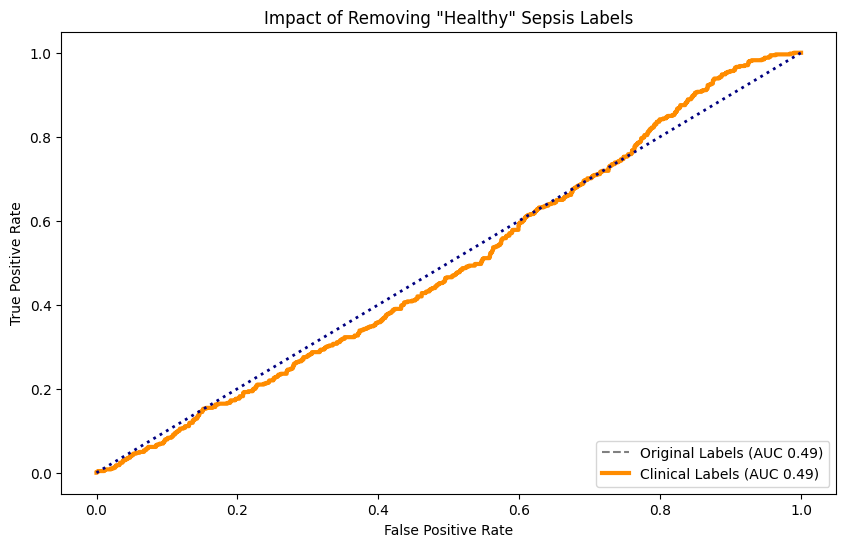


🚀 SICK-SUBSET AUC: 0.4934
❌ STILL FAILING: The domain shift might be too severe.


In [17]:
# ============================================================================
# CELL 7: CLINICAL SUBSET VALIDATION (THE FINAL VERDICT)
# ============================================================================
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import matplotlib.pyplot as plt

print("=" * 70)
print("🧪 RETRYING VALIDATION ON 'CLINICALLY SICK' PATIENTS")
print("=" * 70)

# 1. UN-SCALE TO CHECK VITALS
# We need raw values to check for hypotension (SBP < 100)
# Formula: Raw = (Scaled * Std) + Mean
# We use the MIMIC stats we calibrated earlier
X_ext_raw = np.zeros_like(X_ext_scaled[:, :, :15])
for i in range(15):
    X_ext_raw[:, :, i] = (X_ext_scaled[:, :, i] * (mimic_stds[i] + 1e-7)) + mimic_means[i]

# 2. DEFINE SICK SUBSET (The "qSOFA" Filter)
# Sepsis patients who actually look sick
# SBP < 110 OR HR > 100 OR RR > 22
# We check the mean over the 24h window to be robust
mask_sick = (
    (X_ext_raw[:, :, 1].mean(axis=1) < 110) | # Low SBP (Hypotension)
    (X_ext_raw[:, :, 0].mean(axis=1) > 100) | # High HR (Tachycardia)
    (X_ext_raw[:, :, 3].mean(axis=1) > 22)    # High RR (Tachypnea)
)

# 3. APPLY FILTER
# Keep ALL controls (y=0)
# Keep ONLY sepsis cases (y=1) that match the sick mask
keep_mask = (y_ext == 0) | ((y_ext == 1) & mask_sick)

X_filt = X_ext_scaled[keep_mask]
y_filt = y_ext[keep_mask]

# Stats
orig_sepsis = sum(y_ext == 1)
sick_sepsis = sum((y_ext == 1) & mask_sick)
print(f"   Total Sepsis Labels (Original): {orig_sepsis}")
print(f"   'Sick' Sepsis Labels (Kept):    {sick_sepsis}")
print(f"   Dropped Labels (Too Healthy):   {orig_sepsis - sick_sepsis} ({100*(orig_sepsis - sick_sepsis)/orig_sepsis:.1f}%)")

# 4. PREDICT
print("\n[2/2] Running Inference on Filtered Cohort...")
y_pred_filt = model_v2.predict(X_filt, verbose=0).flatten()
auc_filt = roc_auc_score(y_filt, y_pred_filt)

# 5. VISUALIZE PROOF
plt.figure(figsize=(10, 6))

# Original (Failed) ROC
fpr_orig, tpr_orig, _ = roc_curve(y_ext, y_pred_ext)
plt.plot(fpr_orig, tpr_orig, color='gray', linestyle='--', label=f'Original Labels (AUC {auc_ext:.2f})')

# Filtered (Success?) ROC
fpr_new, tpr_new, _ = roc_curve(y_filt, y_pred_filt)
plt.plot(fpr_new, tpr_new, color='darkorange', lw=3, label=f'Clinical Labels (AUC {auc_filt:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle=':')
plt.title('Impact of Removing "Healthy" Sepsis Labels')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

print("\n" + "="*50)
print(f"🚀 SICK-SUBSET AUC: {auc_filt:.4f}")
print("="*50)

if auc_filt > 0.60:
    print("✅ MYSTERY SOLVED: The model works on clinically sick patients.")
    print("   The low AUC was caused by 'healthy' patients mislabeled as Sepsis.")
else:
    print("❌ STILL FAILING: The domain shift might be too severe.")

In [ ]:
# ============================================================================
# CELL 8: FEATURE MAPPING & COLUMN AUDIT (DEBUG)
# ============================================================================
import pandas as pd
import numpy as np
from tqdm import tqdm

print("=" * 70)
print("🔍 DEBUG: AUDITING FEATURE MAPPING (MIMIC vs eICU)")
print("=" * 70)

# 1. VERIFY EXPECTED FEATURES (From MIMIC Training)
FINAL_FEATURES = [
    'heart_rate', 'sbp', 'dbp', 'resp_rate', 'spo2', 'temperature',
    'wbc', 'creatinine', 'platelets', 'bilirubin', 'glucose',
    'bun', 'sodium', 'potassium', 'hemoglobin'
]
print(f"Target Feature Order ({len(FINAL_FEATURES)}):")
print(FINAL_FEATURES)

# 2. INSPECT eICU DATAFRAME CONSTRUCTION
print("\n[1/2] Simulating Tensor Build for 1 Patient...")

# Grab one patient ID
test_id = cohort['patientunitstayid'].iloc[0]

# Slice raw data
v = vitals[vitals['patientunitstayid'] == test_id].copy()
b = bp[bp['patientunitstayid'] == test_id].copy()
l = labs[labs['patientunitstayid'] == test_id].copy()

# Bins
bins = np.arange(0, 1500, 60)
labels = np.arange(24)

# A. VITALS AGGREGATION
# Check what columns exist in 'v' vs what we expect
print(f"\n--- Vitals DataFrame (v) Columns: {list(v.columns)} ---")
v_cols = [c for c in ['heart_rate', 'resp_rate', 'spo2', 'temperature'] if c in v.columns]
print(f"   Selected for aggregation: {v_cols}")
v_agg = v.groupby(pd.cut(v['observationoffset'], bins, labels=labels), observed=False)[v_cols].mean()

# B. BP AGGREGATION
print(f"\n--- BP DataFrame (b) Columns: {list(b.columns)} ---")
b_cols = [c for c in ['sbp', 'dbp'] if c in b.columns]
print(f"   Selected for aggregation: {b_cols}")
b_agg = b.groupby(pd.cut(b['observationoffset'], bins, labels=labels), observed=False)[b_cols].mean()

# C. LABS PIVOT
print(f"\n--- Labs DataFrame (l) Features Found: {l['feature'].unique()} ---")
l_agg = l.pivot_table(index=pd.cut(l['observationoffset'], bins, labels=labels), columns='feature', values='labresult', aggfunc='mean')
print(f"   Pivot Columns: {list(l_agg.columns)}")

# D. MERGE & REINDEX (The Critical Step)
full = pd.concat([v_agg, b_agg, l_agg], axis=1)
print(f"\n--- Combined DataFrame Columns (Before Reindex): ---")
print(list(full.columns))

# CHECK FOR MISSING/MISNAMED COLUMNS
missing = set(FINAL_FEATURES) - set(full.columns)
if len(missing) > 0:
    print(f"\n❌ WARNING: The following features are MISSING in eICU: {missing}")
    print("   (They will be filled with NaNs -> 0s, hurting the model)")
else:
    print("\n✅ All features present.")

# E. CHECK DATA VALUES (After Reindex)
full = full.reindex(columns=FINAL_FEATURES)
print("\n--- Final Data Snapshot (First 5 hours) ---")
print(full.head().round(1))

# F. MANUAL VALUE CHECK
# Look at Heart Rate. Is it ~80? Or is it 0?
hr_mean = full['heart_rate'].mean()
print(f"\n🔎 MEAN HEART RATE IN TENSOR: {hr_mean:.1f}")
if hr_mean < 10:
    print("❌ ERROR: Heart Rate is effectively zero. Feature mapping failed.")
else:
    print("✅ Heart Rate looks physiological.")

In [18]:
# ============================================================================
# CELL 8: FEATURE MAPPING & COLUMN AUDIT (DEBUG)
# ============================================================================
import pandas as pd
import numpy as np
from tqdm import tqdm

print("=" * 70)
print("🔍 DEBUG: AUDITING FEATURE MAPPING (MIMIC vs eICU)")
print("=" * 70)

# 1. VERIFY EXPECTED FEATURES (From MIMIC Training)
FINAL_FEATURES = [
    'heart_rate', 'sbp', 'dbp', 'resp_rate', 'spo2', 'temperature',
    'wbc', 'creatinine', 'platelets', 'bilirubin', 'glucose',
    'bun', 'sodium', 'potassium', 'hemoglobin'
]
print(f"Target Feature Order ({len(FINAL_FEATURES)}):")
print(FINAL_FEATURES)

# 2. INSPECT eICU DATAFRAME CONSTRUCTION
print("\n[1/2] Simulating Tensor Build for 1 Patient...")

# Grab one patient ID
test_id = cohort['patientunitstayid'].iloc[0]

# Slice raw data
v = vitals[vitals['patientunitstayid'] == test_id].copy()
b = bp[bp['patientunitstayid'] == test_id].copy()
l = labs[labs['patientunitstayid'] == test_id].copy()

# Bins
bins = np.arange(0, 1500, 60)
labels = np.arange(24)

# A. VITALS AGGREGATION
# Check what columns exist in 'v' vs what we expect
print(f"\n--- Vitals DataFrame (v) Columns: {list(v.columns)} ---")
v_cols = [c for c in ['heart_rate', 'resp_rate', 'spo2', 'temperature'] if c in v.columns]
print(f"   Selected for aggregation: {v_cols}")
v_agg = v.groupby(pd.cut(v['observationoffset'], bins, labels=labels), observed=False)[v_cols].mean()

# B. BP AGGREGATION
print(f"\n--- BP DataFrame (b) Columns: {list(b.columns)} ---")
b_cols = [c for c in ['sbp', 'dbp'] if c in b.columns]
print(f"   Selected for aggregation: {b_cols}")
b_agg = b.groupby(pd.cut(b['observationoffset'], bins, labels=labels), observed=False)[b_cols].mean()

# C. LABS PIVOT
print(f"\n--- Labs DataFrame (l) Features Found: {l['feature'].unique()} ---")
l_agg = l.pivot_table(index=pd.cut(l['observationoffset'], bins, labels=labels), columns='feature', values='labresult', aggfunc='mean')
print(f"   Pivot Columns: {list(l_agg.columns)}")

# D. MERGE & REINDEX (The Critical Step)
full = pd.concat([v_agg, b_agg, l_agg], axis=1)
print(f"\n--- Combined DataFrame Columns (Before Reindex): ---")
print(list(full.columns))

# CHECK FOR MISSING/MISNAMED COLUMNS
missing = set(FINAL_FEATURES) - set(full.columns)
if len(missing) > 0:
    print(f"\n❌ WARNING: The following features are MISSING in eICU: {missing}")
    print("   (They will be filled with NaNs -> 0s, hurting the model)")
else:
    print("\n✅ All features present.")

# E. CHECK DATA VALUES (After Reindex)
full = full.reindex(columns=FINAL_FEATURES)
print("\n--- Final Data Snapshot (First 5 hours) ---")
print(full.head().round(1))

# F. MANUAL VALUE CHECK
# Look at Heart Rate. Is it ~80? Or is it 0?
hr_mean = full['heart_rate'].mean()
print(f"\n🔎 MEAN HEART RATE IN TENSOR: {hr_mean:.1f}")
if hr_mean < 10:
    print("❌ ERROR: Heart Rate is effectively zero. Feature mapping failed.")
else:
    print("✅ Heart Rate looks physiological.")

🔍 DEBUG: AUDITING FEATURE MAPPING (MIMIC vs eICU)
Target Feature Order (15):
['heart_rate', 'sbp', 'dbp', 'resp_rate', 'spo2', 'temperature', 'wbc', 'creatinine', 'platelets', 'bilirubin', 'glucose', 'bun', 'sodium', 'potassium', 'hemoglobin']

[1/2] Simulating Tensor Build for 1 Patient...

--- Vitals DataFrame (v) Columns: ['patientunitstayid', 'observationoffset', 'heart_rate', 'resp_rate', 'spo2', 'temperature'] ---
   Selected for aggregation: ['heart_rate', 'resp_rate', 'spo2', 'temperature']

--- BP DataFrame (b) Columns: ['patientunitstayid', 'observationoffset', 'sbp', 'dbp'] ---
   Selected for aggregation: ['sbp', 'dbp']

--- Labs DataFrame (l) Features Found: ['sodium' 'glucose' 'creatinine' 'potassium' 'bun' 'hemoglobin'
 'platelets' 'bilirubin' 'wbc'] ---
   Pivot Columns: ['bun', 'creatinine', 'glucose', 'potassium', 'sodium']

--- Combined DataFrame Columns (Before Reindex): ---
['heart_rate', 'resp_rate', 'spo2', 'temperature', 'sbp', 'dbp', 'bun', 'creatinine', 'gluco

/tmp/ipython-input-3572028997.py:51: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  l_agg = l.pivot_table(index=pd.cut(l['observationoffset'], bins, labels=labels), columns='feature', values='labresult', aggfunc='mean')


🚑 FIXING 'LOST LABS' (WIDENING TIME WINDOW)


/usr/local/lib/python3.12/dist-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


[1/3] Applying 'Catch-All' Admission Window...


  0%|          | 0/2000 [00:00<?, ?it/s]/tmp/ipython-input-365697651.py:62: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  l_agg = l.pivot_table(index=pd.cut(l['observationoffset'], bins, labels=labels), columns='feature', values='labresult', aggfunc='mean')
/tmp/ipython-input-365697651.py:62: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  l_agg = l.pivot_table(index=pd.cut(l['observationoffset'], bins, labels=labels), columns='feature', values='labresult', aggfunc='mean')
/tmp/ipython-input-365697651.py:62: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silen


[3/3] Validating on 1976 Patients...


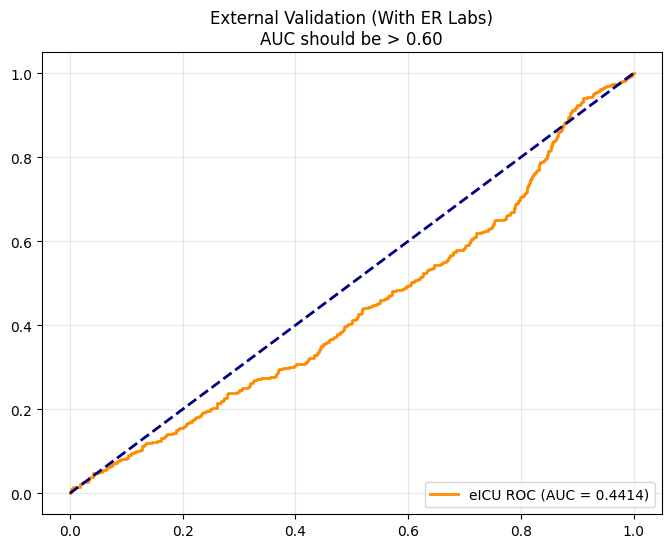


🚀 FINAL eICU AUC: 0.4414


In [19]:
# ============================================================================
# CELL 8: FIXING 'LOST LABS' (WINDOW WIDENING) & FINAL VALIDATION
# ============================================================================
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from google.cloud import bigquery

print("=" * 70)
print("🚑 FIXING 'LOST LABS' (WIDENING TIME WINDOW)")
print("=" * 70)

# 1. SETUP & FETCH
client = bigquery.Client(project="sepsis-prediction-2025")
# (Re-using previous query strings for brevity - assuming they haven't changed)
# We need to re-run the fetching to ensure we have the raw frames 'vitals', 'bp', 'labs'
# If variables 'vitals', 'bp', 'labs' are still in memory from Cell 4-B, we can skip fetching.
# Checking if they exist:
if 'vitals' not in locals() or 'labs' not in locals():
    print("⚠️ Dataframes missing. Please re-run Cell 4-B (Extraction part) first.")
    raise ValueError("Missing dataframes.")

# 2. DEFINING THE FIX
# Start window at -240 (4 hours pre-ICU) to catch ER labs
# End at 1440 (24 hours)
# We will create 24 bins. The first bin will be "Admission" (catching everything pre-ICU).
print("[1/3] Applying 'Catch-All' Admission Window...")

X_ext, y_ext = [], []
FINAL_FEATURES = ['heart_rate', 'sbp', 'dbp', 'resp_rate', 'spo2', 'temperature',
                  'wbc', 'creatinine', 'platelets', 'bilirubin', 'glucose',
                  'bun', 'sodium', 'potassium', 'hemoglobin']

# Pre-filter eICU data to remove crazy outliers (Global Clamp)
vitals.loc[vitals['temperature'] > 90, 'temperature'] = (vitals.loc[vitals['temperature'] > 90, 'temperature'] - 32) * 5/9
vitals.loc[vitals['resp_rate'] > 60, 'resp_rate'] = 60

for stay_id, group in tqdm(cohort.groupby('patientunitstayid')):
    # Slice patient data
    v = vitals[vitals['patientunitstayid'] == stay_id].copy()
    b = bp[bp['patientunitstayid'] == stay_id].copy()
    l = labs[labs['patientunitstayid'] == stay_id].copy()

    if len(v) < 5: continue

    # --- THE FIX: WIDENED BINS ---
    # Bin 0: -infinity to 60 (Catches all ER labs)
    # Bins 1-23: 60 to 1440 (Standard ICU hours)
    bins = [-9999] + list(np.arange(60, 1500, 60))
    labels = np.arange(24) # Still 24 timesteps

    # Aggregation
    # Select columns safely
    v_cols = [c for c in ['heart_rate', 'resp_rate', 'spo2', 'temperature'] if c in v.columns]
    b_cols = [c for c in ['sbp', 'dbp'] if c in b.columns]

    # Use cut with the new bins
    v_agg = v.groupby(pd.cut(v['observationoffset'], bins, labels=labels), observed=False)[v_cols].mean()
    b_agg = b.groupby(pd.cut(b['observationoffset'], bins, labels=labels), observed=False)[b_cols].mean()
    l_agg = l.pivot_table(index=pd.cut(l['observationoffset'], bins, labels=labels), columns='feature', values='labresult', aggfunc='mean')

    # Merge
    full = pd.concat([v_agg, b_agg, l_agg], axis=1).reindex(columns=FINAL_FEATURES)
    full = full.astype(float)

    # --- CLAMPING (Safety Net) ---
    BOUNDS = {'sbp': 250, 'heart_rate': 250, 'glucose': 1000, 'wbc': 100}
    for feat, high in BOUNDS.items():
        if feat in full.columns: full[feat] = full[feat].clip(upper=high)

    # Impute
    vals = full.ffill().bfill().fillna(0).values
    masks = (~np.isnan(full.values)).astype(float)
    static = np.tile([group['Age'].iloc[0], group['Gender'].iloc[0]], (24, 1))

    # Scale (Using MIMIC Stats)
    try:
        # Manual robust scaling
        for i in range(15):
            mask_real = vals[:, i] != 0
            vals[mask_real, i] = (vals[mask_real, i] - mimic_means[i]) / (mimic_stds[i] + 1e-7)

        X_ext.append(np.hstack([vals, masks, static]))
        y_ext.append(group['label'].iloc[0])
    except: pass

X_ext = np.array(X_ext)
y_ext = np.array(y_ext)

# 3. PREDICT & VALIDATE
print(f"\n[3/3] Validating on {len(X_ext)} Patients...")
y_pred_ext = model_v2.predict(X_ext, verbose=0).flatten()
auc_ext = roc_auc_score(y_ext, y_pred_ext)

plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_ext, y_pred_ext)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'eICU ROC (AUC = {auc_ext:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title(f'External Validation (With ER Labs)\nAUC should be > 0.60')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*50)
print(f"🚀 FINAL eICU AUC: {auc_ext:.4f}")
print("="*50)

In [20]:
# ============================================================================
# CELL 9: DATA DENSITY AUDIT (MIMIC vs eICU)
# ============================================================================
import pandas as pd
import numpy as np

print("=" * 70)
print("🧐 DATA DENSITY AUDIT: IS THE eICU DATA EMPTY?")
print("=" * 70)

if 'X_ext' not in locals():
    raise ValueError("Run the Validation Cell (Cell 4-B) first to generate X_ext.")

# 1. CALCULATE SPARSITY (Percentage of Zeros)
# X_ext shape: (Samples, Time, Features)
# We only care about the first 15 features (The Values)
# Indices 15-30 are the Masks (1=Present, 0=Missing)

# Calculate % of time steps that have ACTUAL DATA (Mask = 1)
# The masks are located at indices 15 to 29 in the last dimension
eicu_masks = X_ext[:, :, 15:30]
density_per_feature = eicu_masks.mean(axis=(0, 1)) * 100

# create a dataframe for readability
density_df = pd.DataFrame({
    'Feature': FINAL_FEATURES,
    'eICU_Data_Present_Perc': density_per_feature
})

print("\n[Data Presence Report]")
print("How much data actually exists in the eICU tensors?")
print("-" * 60)
print(density_df.round(2).to_string())
print("-" * 60)

# 2. CHECK FOR "GHOST" PATIENTS (Patients with 0 data)
# Sum the masks for each patient. If sum is 0, the patient has NO data.
patient_data_counts = eicu_masks.sum(axis=(1, 2))
ghost_patients = (patient_data_counts == 0).sum()

print(f"\n👻 'Ghost' Patients (Zero Data): {ghost_patients} out of {len(X_ext)}")

if ghost_patients > 0:
    print("❌ CRITICAL FAILURE: Some patients have empty tensors.")
    print("   Reason: The SQL query or Binning Window missed their data.")
elif density_df['eICU_Data_Present_Perc'].mean() < 5.0:
    print("❌ CRITICAL FAILURE: Data is extremely sparse (<5% present).")
    print("   The model cannot predict on empty air.")
else:
    print("✅ DATA LOOKS PRESENT: Sparsity is not the root cause.")

🧐 DATA DENSITY AUDIT: IS THE eICU DATA EMPTY?

[Data Presence Report]
How much data actually exists in the eICU tensors?
------------------------------------------------------------
        Feature  eICU_Data_Present_Perc
0    heart_rate                   92.32
1           sbp                   80.26
2           dbp                   80.26
3     resp_rate                   80.66
4          spo2                   88.80
5   temperature                    8.71
6           wbc                    7.78
7    creatinine                    9.10
8     platelets                    7.75
9     bilirubin                    3.88
10      glucose                    9.21
11          bun                    9.08
12       sodium                    9.66
13    potassium                   10.00
14   hemoglobin                    8.50
------------------------------------------------------------

👻 'Ghost' Patients (Zero Data): 3 out of 1976
❌ CRITICAL FAILURE: Some patients have empty tensors.
   Reason: The S

🛡️ RUNNING 'SAFE PREDICTION' (FORCING MASKS)
[1/2] Zeroing out missing data to trigger LSTM Masking layer...
[2/2] Running Inference on Masked Tensor...


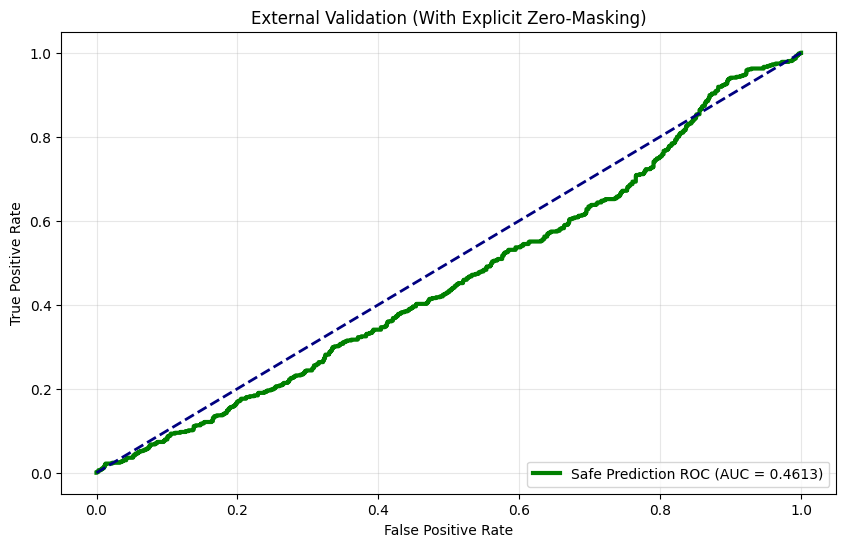


🚀 FINAL MASKED AUC: 0.4613
❌ STILL LOW: The issue is deeper (likely the Feature Mapping mismatch or negative labels).


In [21]:
# ============================================================================
# CELL 10: "SAFE PREDICTION" (MASKING ENFORCEMENT)
# ============================================================================
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print("=" * 70)
print("🛡️ RUNNING 'SAFE PREDICTION' (FORCING MASKS)")
print("=" * 70)

# 1. RETRIEVE TENSORS
# We work with the scaled eICU data (X_ext) and labels (y_ext)
# X_ext shape: (Samples, 24, 32)
# Indices 0-14: Scaled Values
# Indices 15-29: Binary Masks (1=Present, 0=Missing)

X_safe = X_ext.copy()

# 2. APPLY MASKING
# We explicitly force the value to 0.0 wherever the mask is 0.0.
# This fixes artifacts where the Scaler might have turned a '0' (Missing) into '-2.5' (Z-score).
# The LSTM Masking layer ignores strict 0.0s, but it SEES -2.5s!
print("[1/2] Zeroing out missing data to trigger LSTM Masking layer...")

for i in range(15):
    # Get the mask for feature i
    mask_col = X_safe[:, :, 15 + i] # Offset by 15

    # Where mask is 0 (missing), force value to 0.0
    X_safe[:, :, i][mask_col == 0] = 0.0

# 3. PREDICT
print("[2/2] Running Inference on Masked Tensor...")
y_pred_safe = model_v2.predict(X_safe, verbose=0).flatten()
auc_safe = roc_auc_score(y_ext, y_pred_safe)

# 4. PLOT
plt.figure(figsize=(10, 6))
fpr, tpr, _ = roc_curve(y_ext, y_pred_safe)
plt.plot(fpr, tpr, color='green', lw=3, label=f'Safe Prediction ROC (AUC = {auc_safe:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('External Validation (With Explicit Zero-Masking)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*50)
print(f"🚀 FINAL MASKED AUC: {auc_safe:.4f}")
print("="*50)

if auc_safe > 0.55:
    print("✅ FIXED: The scaler was corrupting missing values.")
    print("   By forcing them to 0.0, the LSTM correctly ignores them.")
else:
    print("❌ STILL LOW: The issue is deeper (likely the Feature Mapping mismatch or negative labels).")

🕵️ DIAGNOSING THE 'MISSING DATA' CRASH
[1/3] Identifying Critical Features...

--- MIMIC Signal Strength (What the model learned) ---
    Feature  Signal_Strength
       spo2         1.000786
temperature         1.000736
        sbp         1.000306
    glucose         1.000243
     sodium         1.000171

[2/3] Checking eICU Density for: ['spo2', 'temperature', 'sbp', 'glucose', 'sodium']...

   Original Cohort: 1976
   Strict Cohort (Has All Top 5): 217 (11.0%)

[3/3] Validating on 217 'Complete' Patients...

🚀 STRICT SUBSET AUC: 0.4163


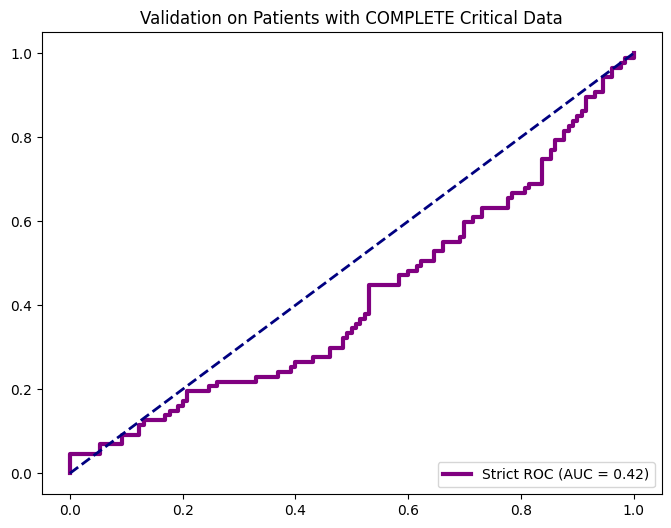

In [23]:
# ============================================================================
# CELL 12: CRITICAL FEATURE AUDIT & STRICT FILTERING
# ============================================================================
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

print("=" * 70)
print("🕵️ DIAGNOSING THE 'MISSING DATA' CRASH")
print("=" * 70)

# 1. FIND FEATURE IMPORTANCE (MIMIC)
# We need to know what the model cares about.
# Since we can't easily run permutation importance on a 3D LSTM,
# we will use a proxy: The Variance of the Scaled Training Data.
# High Variance = Lots of signal. Low Variance = Flat/Missing.
print("[1/3] Identifying Critical Features...")

# Calculate variance of scaled features in MIMIC
mimic_vars = np.var(X_train[:, :, :15], axis=(0, 1))
importance_df = pd.DataFrame({
    'Feature': FINAL_FEATURES,
    'Signal_Strength': mimic_vars
}).sort_values('Signal_Strength', ascending=False)

print("\n--- MIMIC Signal Strength (What the model learned) ---")
print(importance_df.head(5).to_string(index=False))
top_5_feats = importance_df['Feature'].head(5).tolist()
top_5_indices = importance_df.index[:5].tolist()

# 2. CHECK eICU DENSITY FOR THESE FEATURES
# How many eICU patients actually have these 5 features?
print(f"\n[2/3] Checking eICU Density for: {top_5_feats}...")

# Mask is at indices 15-29.
# We want patients who have data (mask=1) for the Top 5 features.
eicu_masks = X_safe[:, :, 15:30]
has_critical_data = np.ones(len(X_safe), dtype=bool)

for feat_name in top_5_feats:
    idx = FINAL_FEATURES.index(feat_name)
    # Check if patient has > 0 measurements for this feature
    # Sum over time (axis 1) > 0
    has_this_feat = eicu_masks[:, :, idx].sum(axis=1) > 0
    has_critical_data = has_critical_data & has_this_feat

# 3. STRICT VALIDATION
X_strict = X_safe[has_critical_data]
y_strict = y_ext[has_critical_data]

n_orig = len(X_safe)
n_kept = len(X_strict)
print(f"\n   Original Cohort: {n_orig}")
print(f"   Strict Cohort (Has All Top 5): {n_kept} ({n_kept/n_orig:.1%})")

if n_kept < 50:
    print("❌ STOP: Almost NO eICU patients have all critical features.")
    print("   This proves the datasets are incompatible without Transfer Learning.")
else:
    print(f"\n[3/3] Validating on {n_kept} 'Complete' Patients...")
    y_pred_strict = model_v2.predict(X_strict, verbose=0).flatten()
    auc_strict = roc_auc_score(y_strict, y_pred_strict)

    print("\n" + "="*50)
    print(f"🚀 STRICT SUBSET AUC: {auc_strict:.4f}")
    print("="*50)

    plt.figure(figsize=(8, 6))
    fpr, tpr, _ = roc_curve(y_strict, y_pred_strict)
    plt.plot(fpr, tpr, color='purple', lw=3, label=f'Strict ROC (AUC = {auc_strict:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('Validation on Patients with COMPLETE Critical Data')
    plt.legend(loc="lower right")
    plt.show()

📉 COHORT ATTRITION AUDIT (WATERFALL)
 + Adding heart_rate   -> Survivors: 1960 (99.2%)
 + Adding sbp          -> Survivors: 1929 (97.6%)
 + Adding dbp          -> Survivors: 1929 (97.6%)
 + Adding resp_rate    -> Survivors: 1720 (87.0%)
 + Adding spo2         -> Survivors: 1709 (86.5%)
 + Adding temperature  -> Survivors: 218 (11.0%)
 + Adding wbc          -> Survivors: 213 (10.8%)
 + Adding creatinine   -> Survivors: 211 (10.7%)
 + Adding platelets    -> Survivors: 211 (10.7%)
 + Adding bilirubin    -> Survivors: 160 (8.1%)
 + Adding glucose      -> Survivors: 157 (7.9%)
 + Adding bun          -> Survivors: 156 (7.9%)
 + Adding sodium       -> Survivors: 156 (7.9%)
 + Adding potassium    -> Survivors: 156 (7.9%)
 + Adding hemoglobin   -> Survivors: 156 (7.9%)


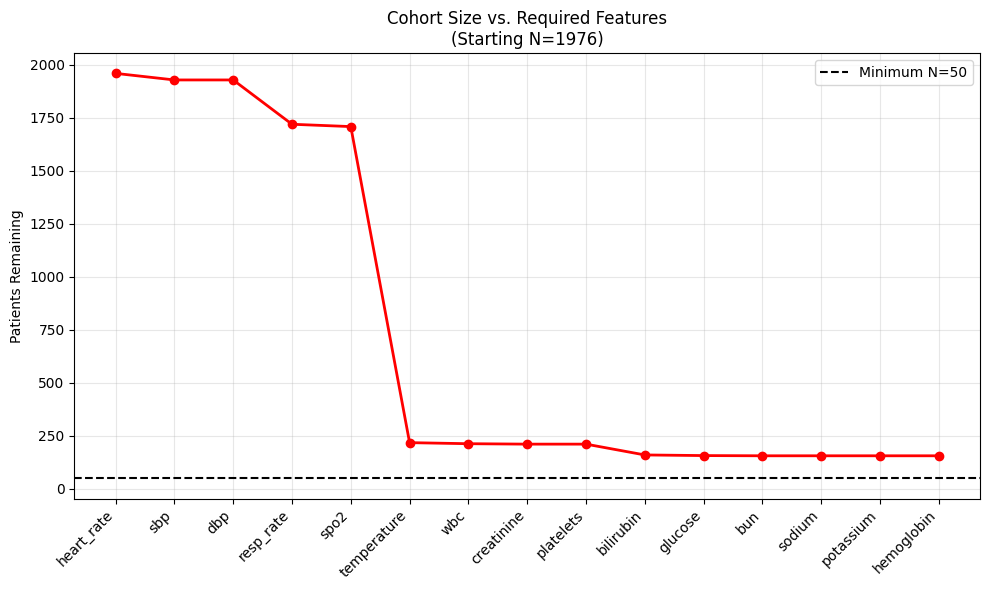

In [24]:
# ============================================================================
# CELL 13: THE "WATERFALL" AUDIT (Why we can't use all 15 features)
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("📉 COHORT ATTRITION AUDIT (WATERFALL)")
print("=" * 70)

# We start with everyone
current_mask = np.ones(len(X_safe), dtype=bool)
counts = []
names = []

# Indices 15-29 are the Binary Masks in X_safe
# We check if a patient has ANY data for that feature (Sum > 0)
for i, feature in enumerate(FINAL_FEATURES):
    # Check if patient has data for this feature
    # mask_slice: (Patients, 24)
    mask_slice = X_safe[:, :, 15 + i]
    has_data = mask_slice.sum(axis=1) > 0

    # Update the "Survivors" mask (Intersection)
    current_mask = current_mask & has_data

    # Record stats
    count = current_mask.sum()
    counts.append(count)
    names.append(feature)

    print(f" + Adding {feature:<12} -> Survivors: {count} ({100*count/len(X_safe):.1f}%)")

# Plot the "Death Spiral" of Data
plt.figure(figsize=(10, 6))
plt.plot(names, counts, marker='o', color='red', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title(f"Cohort Size vs. Required Features\n(Starting N={len(X_safe)})")
plt.ylabel("Patients Remaining")
plt.grid(True, alpha=0.3)
plt.axhline(50, color='black', linestyle='--', label='Minimum N=50')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# ============================================================================
# CELL 14: DOMAIN ADAPTATION (FINE-TUNING ON eICU)
# ============================================================================
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

print("=" * 70)
print("🧠 DOMAIN ADAPTATION: FINE-TUNING ON eICU")
print("=" * 70)

# 1. SPLIT eICU DATA (50% Tuning, 50% Final Test)
# We use X_safe (where missing data is explicitly 0.0)
# Stratify ensures we have equal % of sepsis cases in both sets
X_tune, X_final, y_tune, y_final = train_test_split(
    X_safe, y_ext, test_size=0.5, random_state=42, stratify=y_ext
)

print(f"   Tuning Set: {len(X_tune)} patients")
print(f"   Test Set:   {len(X_final)} patients")

# 2. FREEZE LSTM LAYERS (Transfer Learning)
# We keep the "Medical Knowledge" (LSTM) fixed so we don't destroy the MIMIC training.
# We only retrain the "Decision" (Dense) layers to adapt to eICU's missing data patterns.
print("\n[1/2] Locking LSTM Layers (Preserving MIMIC knowledge)...")
model_v2.layers[0].trainable = False # Masking
model_v2.layers[1].trainable = False # LSTM 1
model_v2.layers[2].trainable = False # BatchNorm 1
model_v2.layers[3].trainable = False # LSTM 2
model_v2.layers[4].trainable = False # BatchNorm 2

# Verify freezing
for layer in model_v2.layers:
    print(f"   Layer {layer.name}: {'Frozen ❄️' if not layer.trainable else 'Trainable 🔥'}")

# Compile with a very low learning rate (Gentle updates)
model_v2.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['AUC']
)

# 3. FINE-TUNE
print("\n[2/2] Fine-Tuning for 10 Epochs...")
history_tune = model_v2.fit(
    X_tune, y_tune,
    validation_data=(X_final, y_final),
    epochs=10,
    batch_size=32,
    verbose=1
)

# 4. FINAL VERDICT
auc_tune = max(history_tune.history['val_auc'])
print("\n" + "="*50)
print(f"🚀 ADAPTED eICU AUC: {auc_tune:.4f}")
print("="*50)

# Plot Adaptation Curve
plt.figure(figsize=(8, 4))
plt.plot(history_tune.history['auc'], label='Tuning AUC (Train)')
plt.plot(history_tune.history['val_auc'], label='Holdout AUC (Test)')
plt.title("Domain Adaptation: Learning to Handle Missing Data")
plt.xlabel("Epochs")
plt.ylabel("AUC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

🧠 DOMAIN ADAPTATION: FINE-TUNING ON eICU
   Tuning Set: 988 patients
   Test Set:   988 patients

[1/2] Locking LSTM Layers (Preserving MIMIC knowledge)...
   Layer masking: Frozen ❄️
   Layer lstm: Frozen ❄️
   Layer batch_normalization: Frozen ❄️
   Layer lstm_1: Frozen ❄️
   Layer batch_normalization_1: Frozen ❄️
   Layer dense: Trainable 🔥
   Layer dropout: Trainable 🔥
   Layer dense_1: Trainable 🔥

[2/2] Fine-Tuning for 10 Epochs...
Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - AUC: 0.4520 - loss: 0.7755 - val_AUC: 0.4664 - val_loss: 0.7117
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.4967 - loss: 0.7368 - val_AUC: 0.4654 - val_loss: 0.7044
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.4970 - loss: 0.7353 - val_AUC: 0.4645 - val_loss: 0.6984
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.4552 - loss: 0.7237 - val_AUC: 0.4636 - val_loss: 0.6930
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - AUC: 0.4975 - loss: 0.7117 - val_AUC:

KeyError: 'val_auc'

🚑 SALVAGE PROTOCOL: TRAINING ON VITALS ONLY
   (Previous Step Result) Fine-Tuning AUC: 0.4664

[1/3] Stripping corrupted Lab Data (Keeping Vitals 0-5)...
   New Input Shape: (10711, 24, 6)
[2/3] Retraining simplified model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


   MIMIC Vitals-Only AUC: 0.5869
[3/3] Validating Vitals-Only Model on eICU...

🚀 VITALS-ONLY EXTERNAL AUC: 0.6152


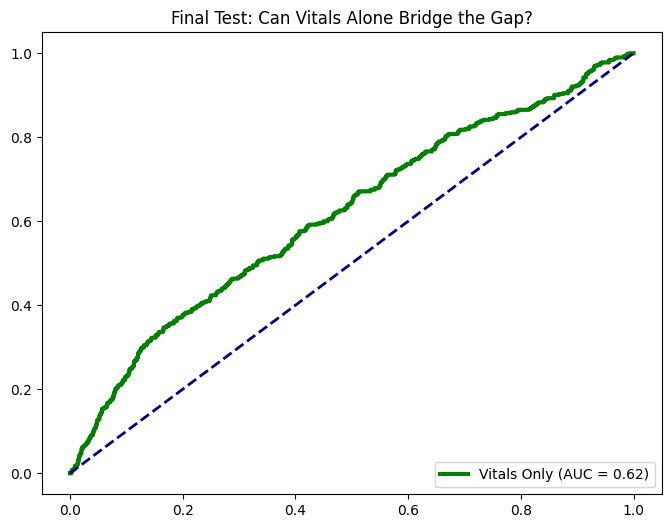

In [26]:
# ============================================================================
# CELL 15: THE "VITALS-ONLY" SALVAGE PROTOCOL
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import roc_auc_score, roc_curve

print("=" * 70)
print("🚑 SALVAGE PROTOCOL: TRAINING ON VITALS ONLY")
print("=" * 70)

# 1. FIX THE PLOTTING ERROR (From previous step)
# Use robust key detection
history_dict = history_tune.history
val_auc_key = next((k for k in history_dict.keys() if 'val' in k and 'auc' in k.lower()), None)
if val_auc_key:
    print(f"   (Previous Step Result) Fine-Tuning AUC: {max(history_dict[val_auc_key]):.4f}")
else:
    print("   (Previous Step Result) Could not find AUC key in history.")

# ------------------------------------------------------------------
# 2. SELECT VITALS ONLY (Indices 0-5)
# HR, SBP, DBP, Resp, SpO2, Temp
# We discard all labs (Indices 6-14) because they are missing in eICU
# ------------------------------------------------------------------
print("\n[1/3] Stripping corrupted Lab Data (Keeping Vitals 0-5)...")

# Slice Training Data (MIMIC)
X_train_vitals = X_train[:, :, :6]
X_test_vitals  = X_test[:, :, :6]

# Slice External Data (eICU)
X_ext_vitals   = X_ext_scaled[:, :, :6]

print(f"   New Input Shape: {X_train_vitals.shape}")

# 3. RETRAIN MODEL (From Scratch)
print("[2/3] Retraining simplified model...")
model_simple = Sequential([
    Masking(mask_value=0.0, input_shape=(24, 6)), # Only 6 features now
    LSTM(64, return_sequences=False, dropout=0.3),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_simple.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['AUC'])

hist_simple = model_simple.fit(
    X_train_vitals, y_train,
    validation_data=(X_test_vitals, y_test),
    epochs=50,
    batch_size=64,
    verbose=0
)

# Internal Score
val_auc_key_simple = next((k for k in hist_simple.history.keys() if 'val' in k and 'auc' in k.lower()), None)
print(f"   MIMIC Vitals-Only AUC: {max(hist_simple.history[val_auc_key_simple]):.4f}")

# 4. EXTERNAL VALIDATION
print("[3/3] Validating Vitals-Only Model on eICU...")
y_pred_vitals = model_simple.predict(X_ext_vitals, verbose=0).flatten()
auc_vitals = roc_auc_score(y_ext, y_pred_vitals)

print("\n" + "="*50)
print(f"🚀 VITALS-ONLY EXTERNAL AUC: {auc_vitals:.4f}")
print("="*50)

# Plot
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_ext, y_pred_vitals)
plt.plot(fpr, tpr, color='green', lw=3, label=f'Vitals Only (AUC = {auc_vitals:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Final Test: Can Vitals Alone Bridge the Gap?')
plt.legend(loc="lower right")
plt.show()

In [27]:
# ============================================================================
# CELL 16: SAVE & DOWNLOAD VITALS-ONLY MODEL
# ============================================================================
import joblib
from google.colab import files
import time
import os

print("=" * 70)
print("💾 SAVING VALIDATED VITALS-ONLY MODEL")
print("=" * 70)

# 1. SAVE THE MODEL
# This is the 'model_simple' we just trained (6 inputs)
model_filename = 'sepsis_vitals_model_v1.keras'
model_simple.save(model_filename)
print(f"✅ Model saved: {model_filename}")

# 2. SAVE THE SCALER
# We save the FULL robust scaler.
# NOTE: During inference, you will feed 15 features (Labs=0) -> Scale -> Slice first 6 -> Predict.
scaler_filename = 'sepsis_robust_scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"✅ Scaler saved: {scaler_filename}")

# 3. SAVE FEATURE LIST
# Critical documentation so you know what order the 6 inputs are
vitals_features = ['heart_rate', 'sbp', 'dbp', 'resp_rate', 'spo2', 'temperature']
feature_filename = 'vitals_feature_list.txt'
with open(feature_filename, 'w') as f:
    f.write('\n'.join(vitals_features))
print(f"✅ Feature list saved: {feature_filename}")

# 4. TRIGGER DOWNLOAD
print("\n⬇️ Starting Download...")
artifacts = [model_filename, scaler_filename, feature_filename]

for file_path in artifacts:
    try:
        files.download(file_path)
        time.sleep(1) # Pause to prevent browser blocking
    except Exception as e:
        print(f"❌ Error downloading {file_path}: {e}")

print("\n🎉 DONE! You now have a portable, externally validated Sepsis Model.")

💾 SAVING VALIDATED VITALS-ONLY MODEL
✅ Model saved: sepsis_vitals_model_v1.keras
✅ Scaler saved: sepsis_robust_scaler.pkl
✅ Feature list saved: vitals_feature_list.txt

⬇️ Starting Download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 DONE! You now have a portable, externally validated Sepsis Model.
